<a href="https://colab.research.google.com/github/romesalarda/comp3226-password-manager-extension/blob/marianna/ecg-arrhythmia-v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Single-Lead ECG Arrhythmia Classification**



Arrhythmia Classification, 5 classes
======================================================

Based on: Md Rabiul Islam – Single Lead Arrhythmia Classification (2023)

Author: Marianna Kottas

Institution: University of Southampton

Programme: BSc Computer Science

Project: Enhancing Patient-Facing Interpretability in an ECG Arrhythmia Classifier

Model: CNN_LSTM with Attention


Dataset
-------
MIT-BIH Arrhythmia Database

• 48 ECG recordings from 47 patients  
• Sampling frequency: 360 Hz  
• Recording length: ~30 minutes per patient  


Task
----
Heartbeat classification into the 5 AAMI categories:

0 – Normal (N)  
1 – Supraventricular ectopic beat (S)  
2 – Ventricular ectopic beat (V)  
3 – Fusion beat (F)  
4 – Unknown / unclassifiable beat (Q)


Pipeline
--------
1. ECG signal loading
2. Wavelet denoising
3. R-peak extraction (using dataset annotations)
4. Heartbeat segmentation (300 samples per beat)
5. Class grouping (15 → 5 AAMI classes)
6. Training set balancing (undersampling + SMOTE)
7. CNN-LSTM classifier
8. Evaluation (accuracy, confusion matrix, per-class metrics)
9. Inference pipeline (prediction + confidence + clinical risk)


Model
-----
CNN-LSTM hybrid neural network implemented in TensorFlow / Keras.


Output
------
Prediction pipeline producing structured output:

{
    "prediction": class_label,
    "confidence": probability_score,
    "risk_level": clinical_risk_category,
    "probabilities": class_probability_vector
}


Purpose
-------
The system is designed for integration into a patient-facing ECG
interpretation dashboard that communicates model predictions,
confidence, and clinical risk in an accessible format.

## **a. Summary, At a Glance**


*   **Task:** Arrhythmia Classification, 5 classes
*   **Dataset:** MIT-BIH ECG dataset, Dataset website: [Here](https://physionet.org/content/mitdb/1.0.0/)
*   **Model:** CNN_LSTM with Attention

## **b. Information about Dataset:**


The dataset can be downloaded from the original [website](https://physionet.org/content/mitdb/1.0.0/) or by clicking the [link](https://physionet.org/static/published-projects/mitdb/mit-bih-arrhythmia-database-1.0.0.zip) directly. The overall information about the dataset is given [here](https://archive.physionet.org/physiobank/database/html/mitdbdir/intro.htm).
1. The MIT-BIH dataset contains **48 readings**.
2. Number of **patients = 47** (25 Men, 22 Women). Only 1 patient has 2 readings. Rest 1 readings/patients.
3. Each reading contains a. ECG signals b. Annotations
4. ECG signals length = **30 Minutes** (or slightly over). Sampling Frequency = **360 Hz**.
5. Each reading contains **2 Lead ECG** signals that are Modified Limb Lead II and Modified Lead V1 (Occationally V2, V5, V4 just only once). Simply, Two Leads: **MLII, V1**.
6. Annotation is given for each beat. Although 20 types of beats are annotated in dataset. We consider only **15 types** of beats grouped in **5 classes** followed by the recommendation of **AAMI**.
* N - Normal
* S - Supraventricular premature beat
* V - Premature ventricular contraction
* F - Fusion of ventricular and normal beat
* Q - Unclassifiable / Unknown beat

### **Additional Dataset Information:**
The source of the ECGs included in the MIT-BIH Arrhythmia Database is a set of over **4000 long-term Holter recordings** that were obtained by the **Beth Israel Hospital** Arrhythmia Laboratory between **1975 and 1979**. Approximately **60%** of these recordings were obtained from **inpatients**. The subjects were 25 men aged 32 to 89 years, and 22 women aged 23 to 89 years

# **Main Parts of the Study:**

1.   **Part A: Installing Packages and Basic Visualization of ECG**
2.   **Part B: Denoising, R-Peak Detection, Segmentation**
3.   **Part C: Dataset Loading**
4.   **Part D: Train-Test Splitting and Class Balancing**
5.   **Part E: Model Building and Training**
6.   **Part F: Results**

# **Part A: Installing Packages and Basic Visualization of ECG**

## **A0: Mount Drive**

In [68]:
# Mount Google Drive + Model Path

from google.colab import drive
import os

# Model location (you already created this folder)
MODEL_DIR = "/content/drive/MyDrive/ecg_model"
MODEL_PATH = MODEL_DIR + "/ecg_model.keras"

# Safety: ensure folder exists
os.makedirs(MODEL_DIR, exist_ok=True)

print("Model path:", MODEL_PATH)


Model path: /content/drive/MyDrive/ecg_model/ecg_model.keras


In [69]:
import os

print("Drive mounted:", os.path.exists("/content/drive/MyDrive"))

print("Folder exists:",
      os.path.exists("/content/drive/MyDrive/ecg_model"))

print("Model exists:",
      os.path.exists("/content/drive/MyDrive/ecg_model/ecg_model.keras"))

!ls /content/drive/MyDrive/ecg_model

Drive mounted: True
Folder exists: True
Model exists: False
best_weights.weights.h5  results


In [75]:
!find /content/drive -name "ecg_model.keras"

## **A1: Installing Packages**

In [6]:
# wfdb is not normally installed in Colab
!pip install wfdb
# For interactive diagram
!pip install neurokit2 plotly

!pip install -q "pandas==2.2.2"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 89.5 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.1 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.

In [7]:
import os, wfdb

BASE = "/content/data"
MIT = os.path.join(BASE, "mitdb")
os.makedirs(MIT, exist_ok=True)

wfdb.dl_database("mitdb", dl_dir=MIT)

project_path = MIT + "/"
DATA_ROOT = MIT
RECORDS = os.path.join(MIT, "RECORDS")

# =================================================
# Output Folders
# =================================================

BASE_OUTPUT = "/content/drive/MyDrive/ecg_model/results"

FIG_DIR = os.path.join(BASE_OUTPUT, "figures")
TAB_DIR = os.path.join(BASE_OUTPUT, "tables")

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)

print("Output folder:", BASE_OUTPUT)

Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 208
Generating record list for: 209
Generati

In [8]:
# Importing packages
import os
import datetime
import wfdb
import pywt
import seaborn
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from os.path import join as osj
from collections import Counter
import pandas as pd

## **A2: Basic Visualization of ECG**
Basic code for loading (reading), plotting and playing with ECG signals

### **a. Getting Recordings' IDs**
The ECG recordings are named after Patients' IDs (from 100 to 234), sorted but not consecutive. Total 48 recordings.

In [9]:
import wfdb

patient_ids = wfdb.get_record_list("mitdb")
patient_ids

['100',
 '101',
 '102',
 '103',
 '104',
 '105',
 '106',
 '107',
 '108',
 '109',
 '111',
 '112',
 '113',
 '114',
 '115',
 '116',
 '117',
 '118',
 '119',
 '121',
 '122',
 '123',
 '124',
 '200',
 '201',
 '202',
 '203',
 '205',
 '207',
 '208',
 '209',
 '210',
 '212',
 '213',
 '214',
 '215',
 '217',
 '219',
 '220',
 '221',
 '222',
 '223',
 '228',
 '230',
 '231',
 '232',
 '233',
 '234']

### **b. 1 Patient ECG loading and plotting**
Extracting 2 leads ECG signals of a patient (for example: 100), and saving in two lists.

In [10]:
#Extracting just 1 patient ECG signal and info
lead0 = {}  # without this it shows lead0[100] is not defined
lead1 = {}
patient_id = 100
signals, info = wfdb.io.rdsamp(osj(DATA_ROOT, str(100)))
lead0[100] = signals[:, 0]
lead1[100] = signals[:, 1]

<class 'numpy.ndarray'>
(650000,)
{'fs': 360, 'sig_len': 650000, 'n_sig': 2, 'base_date': None, 'base_time': None, 'units': ['mV', 'mV'], 'sig_name': ['MLII', 'V5'], 'comments': ['69 M 1085 1629 x1', 'Aldomet, Inderal']}


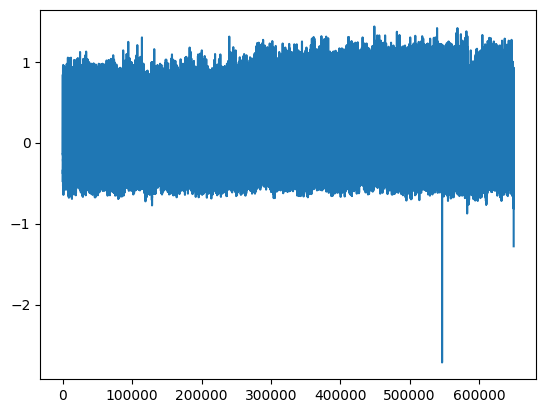

In [11]:
# Visualization of 1 patients signal and info
print(type(lead0[100]))
print(lead0[100].shape)
plt.plot(lead0[100])
print(info)

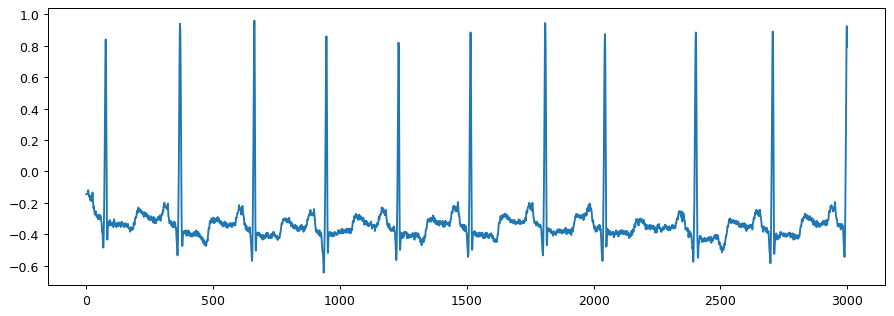

In [12]:
# ECG signal per second
a = lead0[100][0: 3000]
plt.figure(figsize=(12, 4), dpi=90)
plt.plot(a)

### **c. All patients' ECG loading**

In [13]:
# Loading all patients ECG SIGNALs using for loop
def get_ecg_signals(patient_ids):
    lead0 = {}
    lead1 = {}
    for id_ in patient_ids:
        signals, info = wfdb.io.rdsamp(osj(DATA_ROOT, str(id_)))
        lead0[id_] = signals[:, 0]
        lead1[id_] = signals[:, 1]
        print(f'Signal of patient {id_} extracted')
    return lead0, lead1

In [14]:
# Loading all patient ECG INFORMATION
def get_ecg_info(patient_ids):
    _, info = wfdb.io.rdsamp(osj(DATA_ROOT, str(patient_ids)))
    resolution = 2**11  # Number of possible signal values we can have.
    info["resolution"] = 2**11
    return info

In [15]:
lead0, lead1 = get_ecg_signals(patient_ids)

Signal of patient 100 extracted
Signal of patient 101 extracted
Signal of patient 102 extracted
Signal of patient 103 extracted
Signal of patient 104 extracted
Signal of patient 105 extracted
Signal of patient 106 extracted
Signal of patient 107 extracted
Signal of patient 108 extracted
Signal of patient 109 extracted
Signal of patient 111 extracted
Signal of patient 112 extracted
Signal of patient 113 extracted
Signal of patient 114 extracted
Signal of patient 115 extracted
Signal of patient 116 extracted
Signal of patient 117 extracted
Signal of patient 118 extracted
Signal of patient 119 extracted
Signal of patient 121 extracted
Signal of patient 122 extracted
Signal of patient 123 extracted
Signal of patient 124 extracted
Signal of patient 200 extracted
Signal of patient 201 extracted
Signal of patient 202 extracted
Signal of patient 203 extracted
Signal of patient 205 extracted
Signal of patient 207 extracted
Signal of patient 208 extracted
Signal of patient 209 extracted
Signal o

Text(0, 0.5, 'Amplitude (mV)')

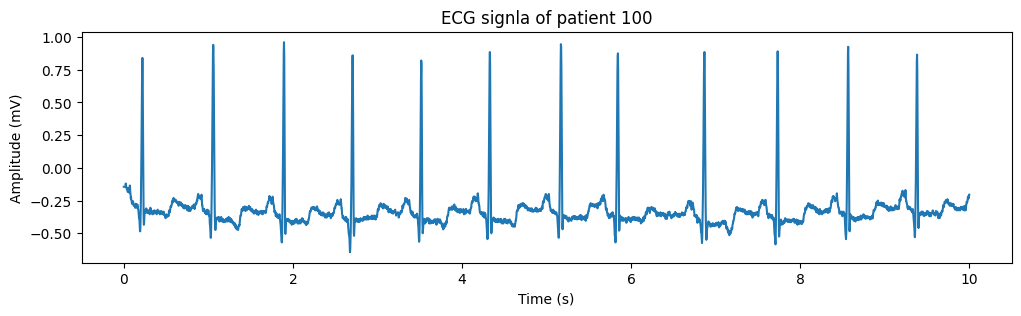

In [16]:
# Plot any patient signal from any time frame
patient_id = "100" # can change
starting_time = 0 # can change
ending_time = 10 # can change

# Scaling
starting_signal_point = starting_time*350
ending_signal_point = ending_time*350 # As sampling frequency is 350 Hz
x = np.arange(starting_time, ending_time, 1/350)
signal = lead0[patient_id][starting_signal_point: ending_signal_point]

plt.figure(figsize=(12, 3), dpi=100)
plt.plot(x, signal)
plt.title(f'ECG signla of patient {patient_id}')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (mV)')

In [17]:
# ECG info of any patient
ecg_info = get_ecg_info(patient_ids[0])
ecg_info

{'fs': 360,
 'sig_len': 650000,
 'n_sig': 2,
 'base_date': None,
 'base_time': None,
 'units': ['mV', 'mV'],
 'sig_name': ['MLII', 'V5'],
 'comments': ['69 M 1085 1629 x1', 'Aldomet, Inderal'],
 'resolution': 2048}

# **Part B: Denoising, R-Peak Detection, Segmentation**

### **B1: Denoising**
Noise removing by using Discrete Wavelet Transform (DCT)

In [18]:
# User defined fucntion for DWT and reconstruction
def denoise(data):
    # wavelet transform
    coeffs = pywt.wavedec(data=data, wavelet='db5', level=9)
    cA9, cD9, cD8, cD7, cD6, cD5, cD4, cD3, cD2, cD1 = coeffs

    # Threshold denoising
    threshold = (np.median(np.abs(cD1)) / 0.6745) * (np.sqrt(2 * np.log(len(cD1))))
    cD1.fill(0)
    cD2.fill(0)
    for i in range(1, len(coeffs) - 2):
        coeffs[i] = pywt.threshold(coeffs[i], threshold)

    # Inverse wavelet transform to obtain the denoised signal
    rdata = pywt.waverec(coeffs=coeffs, wavelet='db5')
    return rdata

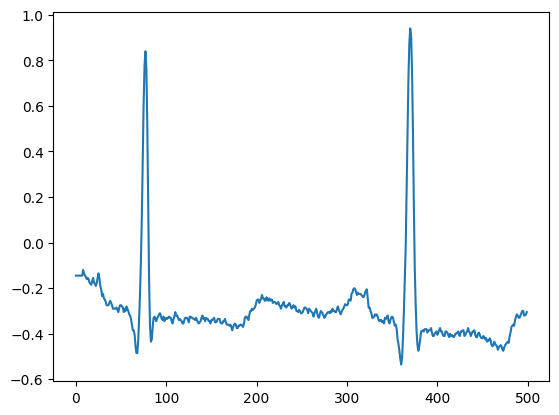

In [19]:
# Ploting a signal before denoising
record = wfdb.rdrecord(project_path + '100', channel_names=['MLII'])
data = record.p_signal.flatten()
plt.plot(data[0:500])

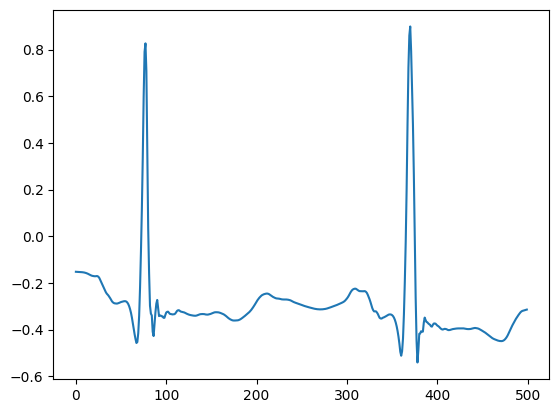

In [20]:
# Same signal after denoising
rdata = denoise(data=data)
plt.plot(rdata[0:500])

### **B2: R-Peak Detection**
R-peak is annotated in MIT-BIH dataset. Just need to read the file.

In [21]:
# For exmaple, we extract '100' recording annotation
annotation = wfdb.rdann(project_path + '100', 'atr')
Rlocation = annotation.sample
print(Rlocation)
Rclass = annotation.symbol
print(Rclass)

[    18     77    370 ... 649484 649734 649991]
['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', '

In [22]:
len(annotation.symbol)

2274

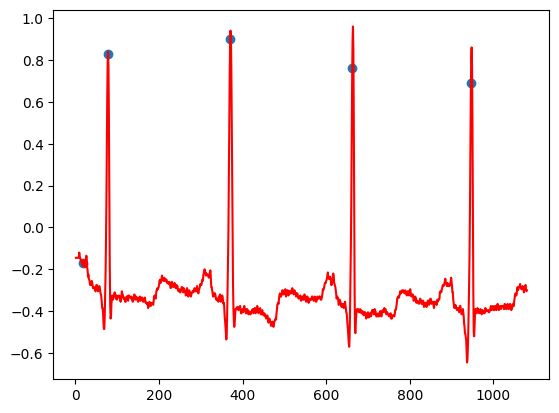

In [23]:
# R-peak ploting
x = np.arange(1, 1081)

n_peak =5
r_peak_x = []
r_peak_y = []
for i in range(0, n_peak):
  r_peak_x.append(Rlocation[i])
  r_peak_y.append(rdata[Rlocation[i]])

plt.plot(x, data[0:1080], color='red')
plt.scatter(r_peak_x, r_peak_y)

### **B3: Segmentation**
Each ECG signal is segmented by using a window **length of 300**. From R-peak location, **99** samples taken from **left** and **201** samples from **right**. Thus a complete **heartbeat** is found.

(300,)
(300,)
(300,)


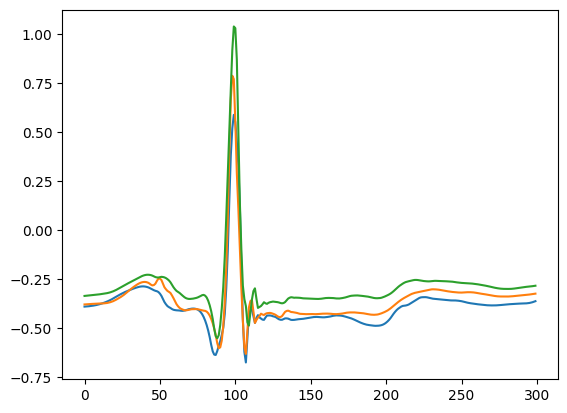

In [24]:
# Plotting 3 heartbeats
k = np.arange(100, 103)
for i in k:
  # print(i)
  # print(Rlocation[i] - 99, Rlocation[i] + 201)
  x_train = rdata[Rlocation[i] - 99:Rlocation[i] + 201]
  plt.plot(x_train)
  print(x_train.shape)
plt.show()

### **B4: Complete Preprocessing Figures**
The complete preprocessing including denosinsing, R-peak location detection and segmentation is expected to view in a single figure.

In [25]:
r_peak_xx = Rlocation[0], Rlocation[1], Rlocation[2], Rlocation[3]
r_peak_yy = rdata[Rlocation[0]], rdata[Rlocation[1]], rdata[Rlocation[2]], rdata[Rlocation[3]]

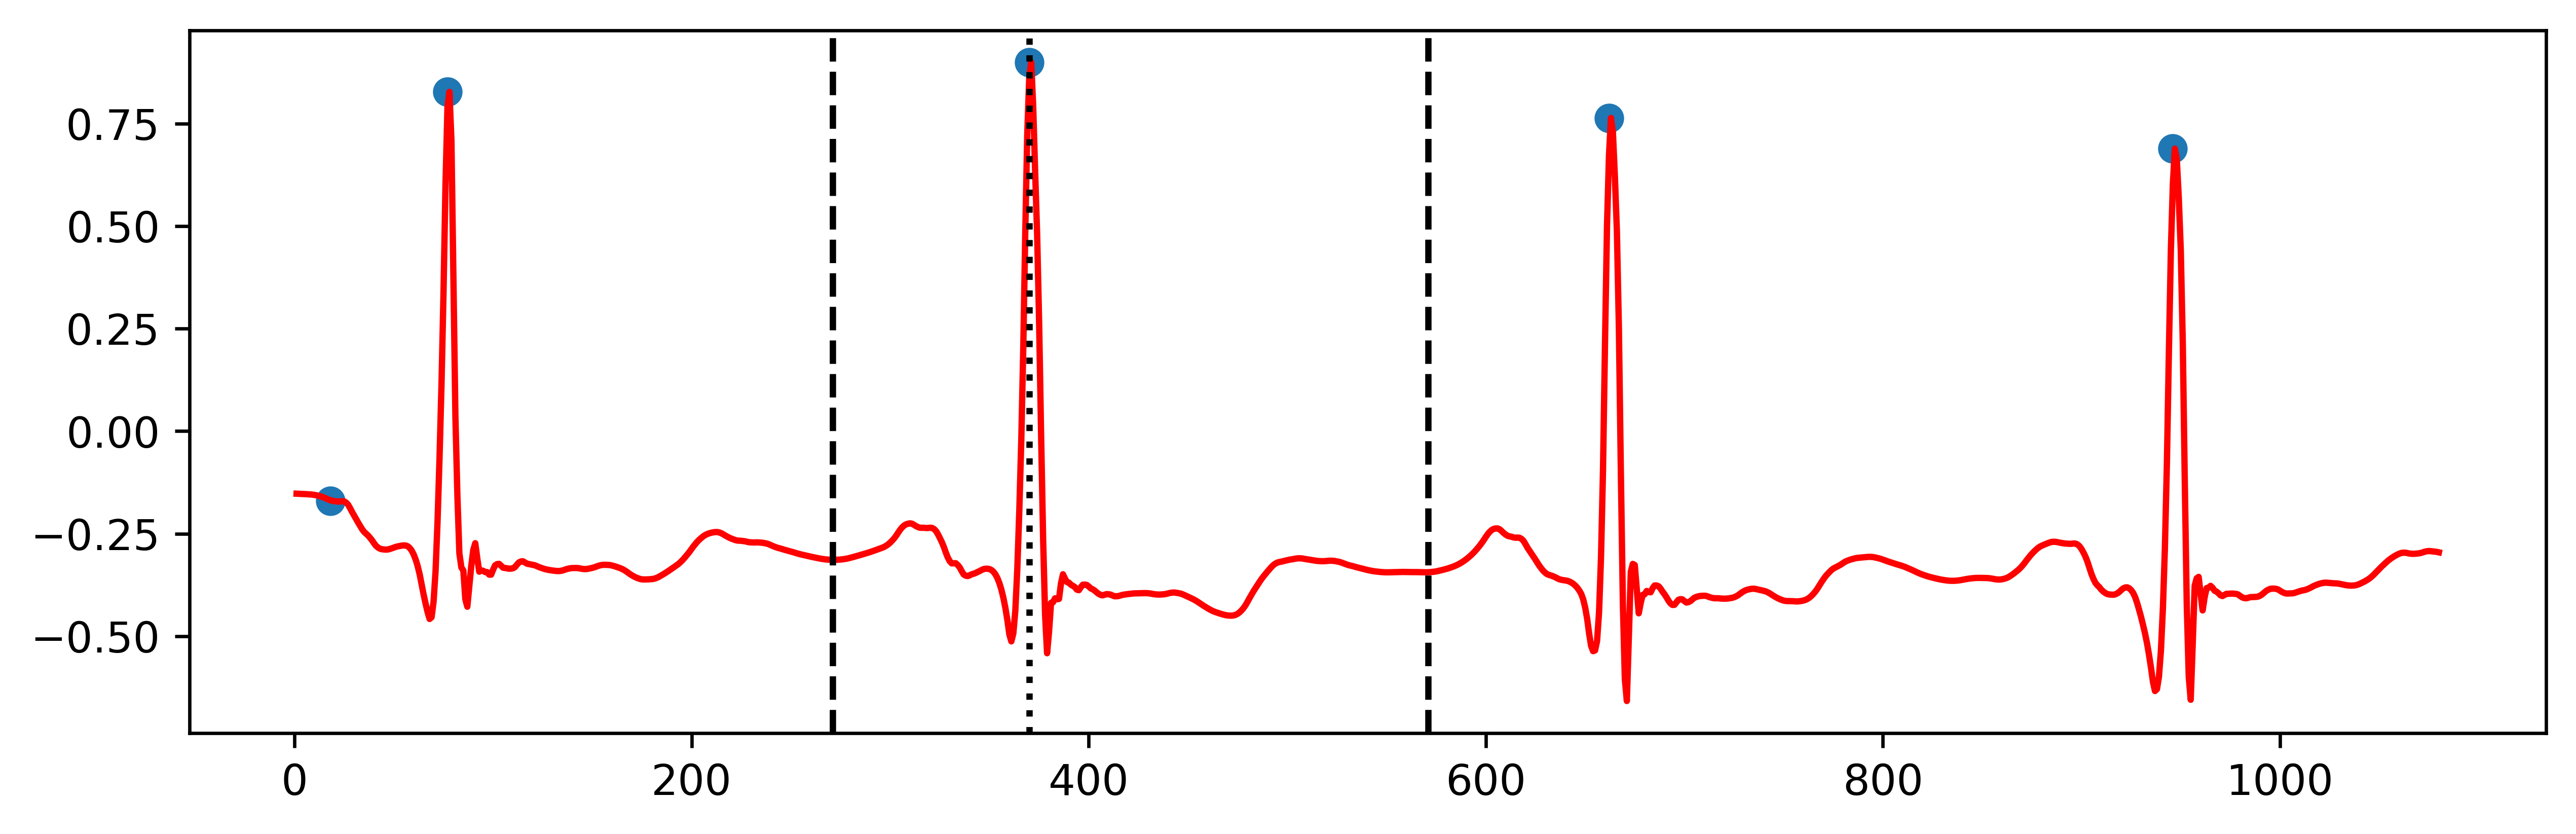

In [26]:
# Plotting R-peaks and segmentation lines
fig = plt.figure(figsize=(10,3), dpi=600)
n_peak =5
r_peak_x = []
r_peak_y = []
for i in range(0, n_peak):
  r_peak_x.append(Rlocation[i])
  r_peak_y.append(rdata[Rlocation[i]])
x = np.arange(1, 1081)
plt.plot(x, rdata[0: 1080], color='red')
plt.scatter(r_peak_x, r_peak_y)

# line plotting
plt.axvline(x = Rlocation[2], color = 'k', linestyle = ':')
plt.axvline(x = Rlocation[2]-99, color = 'k', linestyle = '--')
plt.axvline(x = Rlocation[2]+201, color = 'k', linestyle = '--')

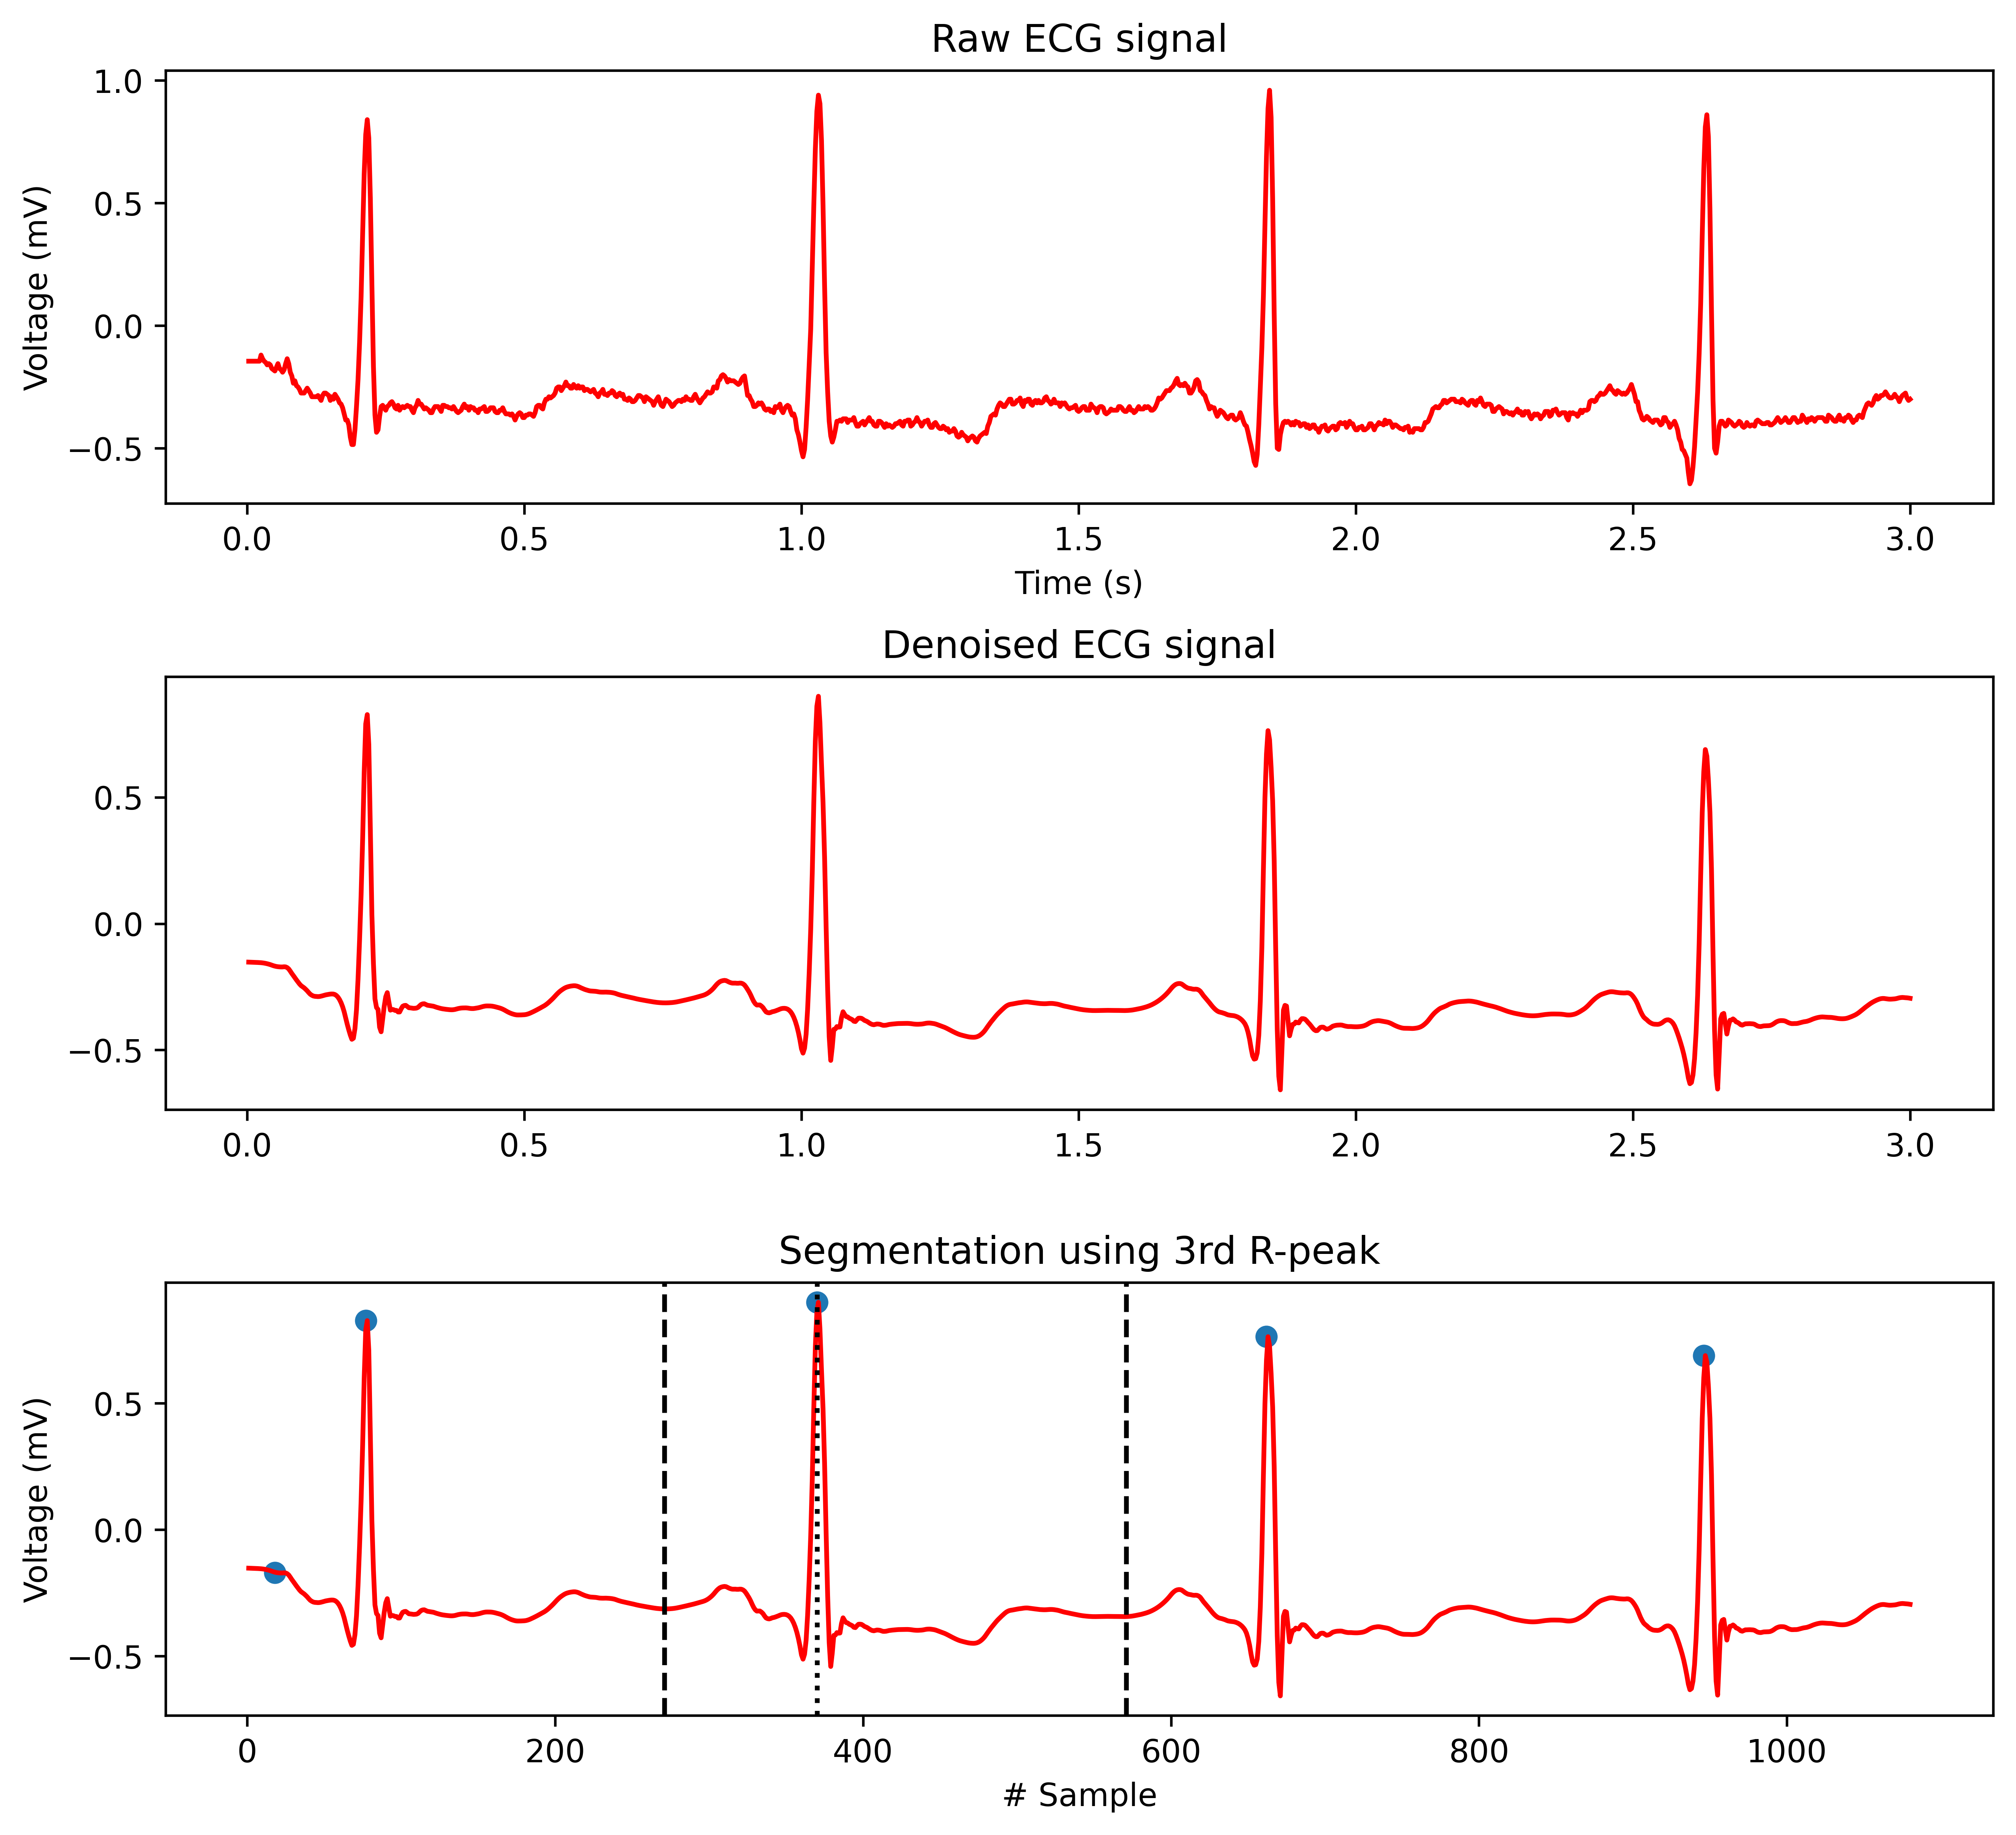

In [27]:
# Plot together raw, denoised and segmted signal
fig = plt.figure(figsize=(10,9), dpi=600)
x = np.arange(1, 1081)

# Raw signal plotting
plt.subplot(3, 1, 1)
plt.plot(x/360, data[0:1080], color='red')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (mV)')
plt.title('Raw ECG signal')

# Denoised signal plotting
plt.subplot(3, 1, 2)
plt.plot(x/360, rdata[0:1080], color='red')
plt.title('Denoised ECG signal')

# Segmentation visualization using two border lines
plt.subplot(3, 1, 3)
n_peak =5
r_peak_x = []
r_peak_y = []
for i in range(0, n_peak):
  r_peak_x.append(Rlocation[i])
  r_peak_y.append(rdata[Rlocation[i]])
x = np.arange(1, 1081)
plt.plot(x, rdata[0: 1080], color='red')
plt.scatter(r_peak_x, r_peak_y)
# line plotting
plt.axvline(x = Rlocation[2], color = 'k', linestyle = ':') # 3rd r-peak
plt.axvline(x = Rlocation[2]-99, color = 'k', linestyle = '--')
plt.axvline(x = Rlocation[2]+201, color = 'k', linestyle = '--')

plt.xlabel('# Sample')
plt.ylabel('Voltage (mV)')
plt.title('Segmentation using 3rd R-peak')

plt.subplots_adjust(left=0.1,
                    bottom=0.1,
                    right=0.9,
                    top=0.9,
                    wspace=0.4,
                    hspace=0.4)

fig.savefig(FIG_DIR + "Denoised_and_segmented_ECG.png")

# **Part C: Dataset Loading**

## **C1: Loading whole data**

In [28]:
# Read ECG signals and corresponding label
def getDataSet(number, X_data, Y_data):

    # Considering 15 types ECG heartbeats that are later grouped in 5 classes
    ecgClassSet = ['N', 'L', 'R', 'e', 'j', 'A', 'a', 'J', 'S', 'V', 'E', 'F', '/', 'f', 'Q']

    # Reading Channel names
    _, info = wfdb.io.rdsamp(osj(project_path, number))
    channels = info['sig_name']
    channel1, channel2 = channels[0], channels[1]
    print(channel1, channel2)


    # Read ECG data records
    print("reading " + number+ " ECG data...")
    record = wfdb.rdrecord(project_path + number, channel_names=[channel1])
    data = record.p_signal.flatten()
    rdata = denoise(data=data)

    # Obtain the position and corresponding label of the R wave in the ECG data record
    annotation = wfdb.rdann(project_path + number, 'atr')
    Rlocation = annotation.sample
    Rclass = annotation.symbol

    # Unstable data before and after removal
    start = 2  # if it creates problem then except will do the job
    end = 3
    i = start
    j = len(annotation.symbol) - end

    # Making labels, Y_data Convert NSVFQ in order to 0123456...14
    while i < j:
        try:
            beat_type = Rclass[i]
            lable = ecgClassSet.index(beat_type)  # when beat is like '+' or other it will go on except loop
            x_train = rdata[Rlocation[i] - 99:Rlocation[i] + 201]
            X_data.append(x_train)
            Y_data.append(lable)
            i += 1
        except ValueError:
            # print(f' when i = {i}, beat type is out of our choise. For example +, [, ! or other')
            i += 1
    return X_data, Y_data

In [29]:
# Load the dataset and preprocess it
def loadData():
    numberSet = ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109',
                 '111', '112', '113', '114', '115', '116', '117', '118', '119', '121',
                 '122', '123', '124', '200', '201', '202', '203', '205', '207', '208',
                 '209', '210', '212', '213', '214', '215', '217', '219', '220', '221',
                 '222', '223', '228', '230', '231', '232', '233', '234'] # 48 readings
    dataSet = []
    lableSet = []
    for n in numberSet:
        # getDataSet(n, dataSet, lableSet)
        dataSet, lableSet = getDataSet(n, dataSet, lableSet)

    # Turn numpy array, scramble the order
    dataSet = np.array(dataSet).reshape(-1, 300)
    lableSet = np.array(lableSet).reshape(-1, 1)
    train_ds = np.hstack((dataSet, lableSet))
    np.random.shuffle(train_ds)

    # dataset and its label set
    X = train_ds[:, :300]
    Y = train_ds[:, 300]
    return X, Y

In [30]:
# Input X and Output Y data loading
X, Y = loadData()

MLII V5
reading 100 ECG data...
MLII V1
reading 101 ECG data...
V5 V2
reading 102 ECG data...
MLII V2
reading 103 ECG data...
V5 V2
reading 104 ECG data...
MLII V1
reading 105 ECG data...
MLII V1
reading 106 ECG data...
MLII V1
reading 107 ECG data...
MLII V1
reading 108 ECG data...
MLII V1
reading 109 ECG data...
MLII V1
reading 111 ECG data...
MLII V1
reading 112 ECG data...
MLII V1
reading 113 ECG data...
V5 MLII
reading 114 ECG data...
MLII V1
reading 115 ECG data...
MLII V1
reading 116 ECG data...
MLII V2
reading 117 ECG data...
MLII V1
reading 118 ECG data...
MLII V1
reading 119 ECG data...
MLII V1
reading 121 ECG data...
MLII V1
reading 122 ECG data...
MLII V5
reading 123 ECG data...
MLII V4
reading 124 ECG data...
MLII V1
reading 200 ECG data...
MLII V1
reading 201 ECG data...
MLII V1
reading 202 ECG data...
MLII V1
reading 203 ECG data...
MLII V1
reading 205 ECG data...
MLII V1
reading 207 ECG data...
MLII V1
reading 208 ECG data...
MLII V1
reading 209 ECG data...
MLII V1
read

In [31]:
# Counting the number of each type of heartbeats
Y_list = list(Y)
Counter(Y_list)

Counter({np.float64(0.0): 74920,
         np.float64(12.0): 7012,
         np.float64(2.0): 7244,
         np.float64(5.0): 2540,
         np.float64(11.0): 802,
         np.float64(1.0): 8063,
         np.float64(9.0): 7123,
         np.float64(13.0): 982,
         np.float64(4.0): 229,
         np.float64(6.0): 150,
         np.float64(10.0): 106,
         np.float64(14.0): 33,
         np.float64(7.0): 83,
         np.float64(3.0): 16,
         np.float64(8.0): 2})

## **C2: Ploting 15 Different Heartbeats**

In [32]:
# making pandas dataframe
df_X = pd.DataFrame(X)
df_Y = pd.DataFrame(Y)

In [33]:
# changing the name from 0 to 300
df_Y.rename(columns = {0:300}, inplace = True)
# join X and Y
df = pd.concat([df_X, df_Y], axis=1)

In [34]:
def Plot_Random_Beat(type, num):

  ecgClassSet = ['N', 'L', 'R', 'e', 'j', 'A', 'a', 'J', 'S', 'V', 'E', 'F', 'slash', 'f', 'Q']

  ecgClassName = ['Normal (N)', 'Left bundle br. bl. (L)', 'Right bundle br. bl. (R)',
                  'Atrial escape (e)', 'Nodal jun. esc. (j)', 'Atrial premature (A)',
                  'Aberrated atrial prem. (a)', 'Nodal jun. pre. (J)',
                  'Supraventricular prem. (S)', 'Premature ventr. (V)',
                  'Ventricular escape (E)', 'Fusion of ve. & no. (F)',
                  'Paced (/)', 'Fusion of pa. & no. (f)',
                  'Unclassifiable(Q)']

  # getting only a specific class ECG signal
  df_0 = df.loc[df[300]==type]  # For normanl class: 0, shape is 74920,301
  df_0 = df_0.drop(columns=[300]) # changing the shape to 74920,300

  # selecting some random row to plot
  if num<=df_0.shape[0]:
    np.random.seed(234)
    random_beat_number = np.random.randint(df_0.shape[0], size=(num))
    random_beat_number = list(random_beat_number)
  else: # Needed for Supraventricular Premature Beat (S) only, as it contains only 2 beats
    print(f"Warning: You have only {df_0.shape[0]} beat, but asked to plot {num}")
    random_beat_number = np.arange(0, df_0.shape[0])
    random_beat_number = list(random_beat_number)

  # ploting the ECG signal
  for i in random_beat_number:
    ecg_beat = df_0.iloc[i]
    plt.plot(ecg_beat)
  plt.title(str(ecgClassName[type]))

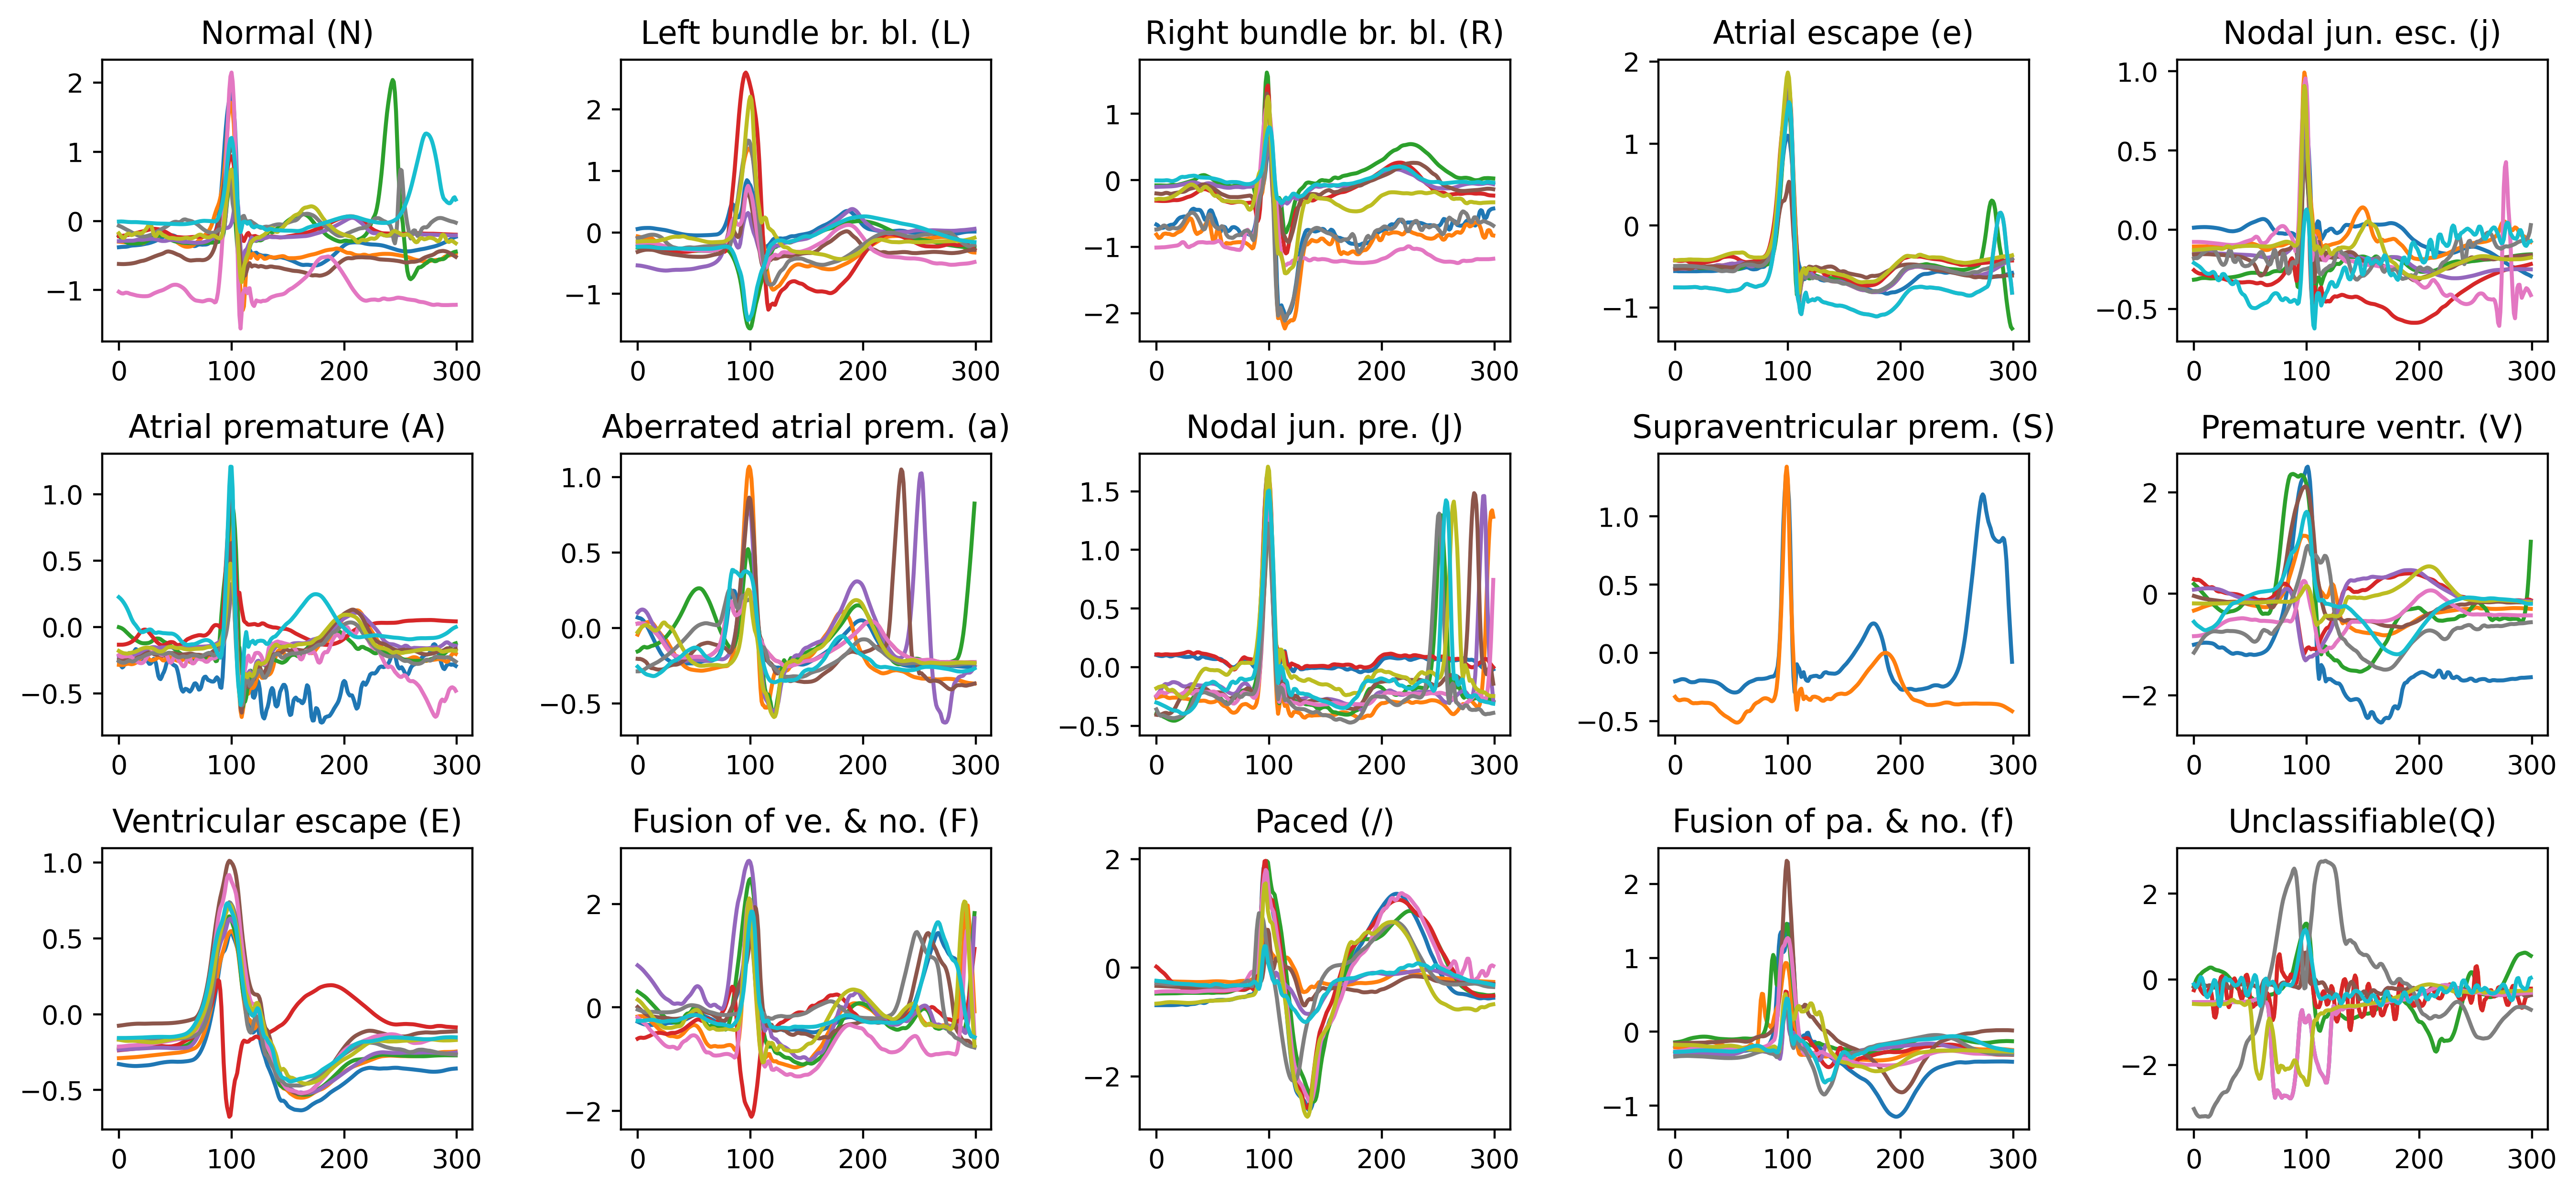

In [35]:
# Plotting 15 different types of heartbeat
fig = plt.figure(figsize=(16,7), dpi=400)
fig.tight_layout(pad=15.0)
for i in range(15):
  plt.subplot(3,5,i+1)
  plt.subplots_adjust(left=0.1,
                    bottom=0.1,
                    right=0.9,
                    top=0.9,
                    wspace=0.4,
                    hspace=0.4)
  Plot_Random_Beat(type=i, num=10)

fig.savefig(FIG_DIR + "all_heartbeats.png")

# **Part D: Train-Test Splitting and Class Balancing**

## **D1: Data loading**
Data is already loaded, **this step can be skipped.** However, here the whole dataset is saved in a train_ds variable.

### **a. Load whole data**

In [36]:
# Load the dataset and preprocess it
def loadData():
    numberSet = ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109',
                 '111', '112', '113', '114', '115', '116', '117', '118', '119', '121',
                 '122', '123', '124', '200', '201', '202', '203', '205', '207', '208',
                 '209', '210', '212', '213', '214', '215', '217', '219', '220', '221',
                 '222', '223', '228', '230', '231', '232', '233', '234']  # 48 readings
    dataSet = []
    lableSet = []
    for n in numberSet:
        # getDataSet(n, dataSet, lableSet)
        dataSet, lableSet = getDataSet(n, dataSet, lableSet)

    # Turn numpy array, scramble the order
    dataSet = np.array(dataSet).reshape(-1, 300)
    lableSet = np.array(lableSet).reshape(-1, 1)
    train_ds = np.hstack((dataSet, lableSet))
    np.random.shuffle(train_ds)
    return train_ds

In [37]:
# Load the whole dataset (109305,301). Each row indicate an ECG beat time series data upto 300
# and 301 colum is its label among 15 difference level
train_ds = loadData()

MLII V5
reading 100 ECG data...
MLII V1
reading 101 ECG data...
V5 V2
reading 102 ECG data...
MLII V2
reading 103 ECG data...
V5 V2
reading 104 ECG data...
MLII V1
reading 105 ECG data...
MLII V1
reading 106 ECG data...
MLII V1
reading 107 ECG data...
MLII V1
reading 108 ECG data...
MLII V1
reading 109 ECG data...
MLII V1
reading 111 ECG data...
MLII V1
reading 112 ECG data...
MLII V1
reading 113 ECG data...
V5 MLII
reading 114 ECG data...
MLII V1
reading 115 ECG data...
MLII V1
reading 116 ECG data...
MLII V2
reading 117 ECG data...
MLII V1
reading 118 ECG data...
MLII V1
reading 119 ECG data...
MLII V1
reading 121 ECG data...
MLII V1
reading 122 ECG data...
MLII V5
reading 123 ECG data...
MLII V4
reading 124 ECG data...
MLII V1
reading 200 ECG data...
MLII V1
reading 201 ECG data...
MLII V1
reading 202 ECG data...
MLII V1
reading 203 ECG data...
MLII V1
reading 205 ECG data...
MLII V1
reading 207 ECG data...
MLII V1
reading 208 ECG data...
MLII V1
reading 209 ECG data...
MLII V1
read

In [38]:
Y = train_ds[:, 300]

In [39]:
# Here 15 class of ECG data are saved
Y_list = list(Y)
Counter(Y_list)

Counter({np.float64(2.0): 7244,
         np.float64(0.0): 74920,
         np.float64(13.0): 982,
         np.float64(12.0): 7012,
         np.float64(9.0): 7123,
         np.float64(1.0): 8063,
         np.float64(5.0): 2540,
         np.float64(11.0): 802,
         np.float64(6.0): 150,
         np.float64(10.0): 106,
         np.float64(4.0): 229,
         np.float64(3.0): 16,
         np.float64(7.0): 83,
         np.float64(14.0): 33,
         np.float64(8.0): 2})

### **b. 15 types to 5 level conversion**

In [40]:
# 15 level to 5 level conversion
Y_5class = np.copy(Y)

for i in range(Y.shape[0]):
  # print(i)
  if 0 <= Y[i] <= 4:
    Y_5class[i] = 0
  if 5 <= Y[i] <= 8:
    Y_5class[i] = 1
  if 9 <= Y[i] <= 10:
    Y_5class[i] = 2
  if Y[i] == 11:
    Y_5class[i] = 3
  if 12 <= Y[i] <= 14:
    Y_5class[i] = 4
print('changing done')

changing done


In [41]:
Y_5class_list = list(Y_5class)
Counter(Y_5class_list)

Counter({np.float64(0.0): 90472,
         np.float64(4.0): 8027,
         np.float64(2.0): 7229,
         np.float64(1.0): 2775,
         np.float64(3.0): 802})

In [42]:
ecg_dataset = np.copy(train_ds)

In [43]:
# label encode the target variable # just convert numpy.float64 to numpy.int64
from sklearn.preprocessing import LabelEncoder
Y_5class = LabelEncoder().fit_transform(Y_5class)

In [44]:
ecg_data = ecg_dataset[:, :300]
ecg_lable = Y_5class.reshape(-1, 1) # otherwise np.hstack will not work

In [45]:
# Complete ECG dataset with 5 type of Arrhythmia
ecg_dataset_5 = np.hstack((ecg_data, ecg_lable))

### **c. Per class data status checking (Full data)**

In [46]:
# Convert ndarray to dataframe
df_ecg = pd.DataFrame(ecg_dataset_5)
class_data = df_ecg[300].value_counts()
class_data

,count
300,
0.0,90472
4.0,8027
2.0,7229
1.0,2775
3.0,802


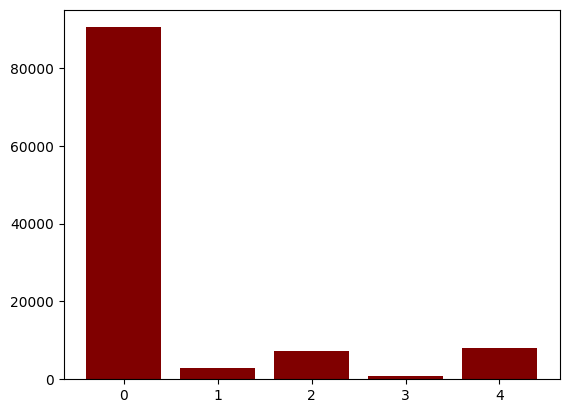

In [47]:
# per class data status plotting,
plt.bar(class_data.index, class_data.values, color ='maroon')
plt.show()

<Axes: xlabel='300'>

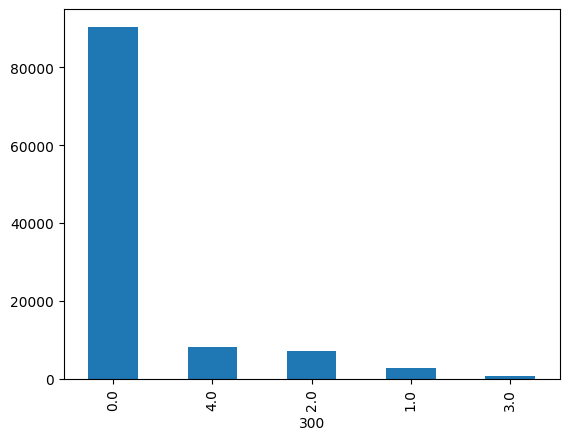

In [48]:
# shortcut for per class data status plotting,
# Order is not maintained by class. Higher to lower
df_ecg[300].value_counts().plot(kind='bar')

## **D2: Train-Test Spliting**
**Note: Class Balance should be done on Training Data Only. Not Testing Data.**

In [49]:
# train test splitting
from sklearn.model_selection import train_test_split
ecg_data = ecg_dataset_5[:, :300]
ecg_label = ecg_dataset_5[:, 300]
x_train, x_test, y_train, y_test = train_test_split(ecg_data, ecg_label,
                                   random_state=104,
                                   test_size=0.20,
                                   shuffle=True)

In [50]:
# reshaping for using hstack function
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)
train_data = np.hstack((x_train, y_train))
test_data = np.hstack((x_test, y_test))

In [51]:
#  converting dataframe
train_data = pd.DataFrame(train_data)
test_data = pd.DataFrame(test_data)

In [52]:
# saving the test data (in imbalanced condition)
file_name = project_path + 'test_data.pkl'
test_data.to_pickle(file_name)

**Training dataset status checking:** balanced / imbalanced

300
0.0    72396
4.0     6421
2.0     5773
1.0     2223
3.0      631
Name: count, dtype: int64


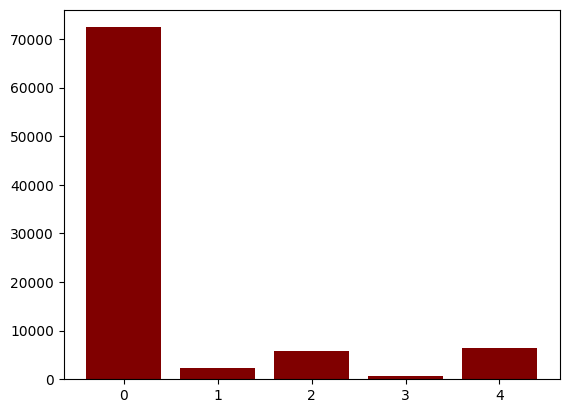

In [53]:
# Imblanced training data graph ploting
class_data = train_data[300].value_counts()
print(class_data)
plt.bar(class_data.index, class_data.values, color ='maroon')
plt.show()

## **D3: Class balancing by undersampling and SMOTE**
**SMOTE** stands for '**Synthetic Minority Oversampling Technique**'.
Plan for train data
1. Class 1: Randomly selected 50000 data
2. Class 1, 2, 3, 4: Use SMOTE to oversample upto 50000 data

In [54]:
# extracting class 0 and 4 others class
train_data_0 = train_data.loc[(train_data[300] == 0)]
train_data_1234 = train_data.loc[(train_data[300] != 0)]

In [55]:
# 1. Class 1: Randomly selected 50000 data
from sklearn.utils import resample
train_data_0_resampled=train_data_0.sample(n=50000,random_state=42)

# convert dataframe to numpy array
train_data_0_resampled = train_data_0_resampled.to_numpy()

In [56]:
# 2. Class 1, 2, 3, 4: Use SMOTE to oversample upto 50000 data

# converting from df to np ndarray
train_data_1234_arr = train_data_1234.to_numpy()
X_4cl, y_4cl = train_data_1234_arr[:, :-1], train_data_1234_arr[:, -1]

from imblearn.over_sampling import SMOTE
# transform the dataset
strategy = {1:50000, 2:50000, 3:50000, 4:50000}
oversample = SMOTE(sampling_strategy=strategy)
X, y = oversample.fit_resample(X_4cl, y_4cl)

y = y.reshape(-1, 1)
train_data_1234_resampled = np.hstack((X, y))

In [57]:
# Join the class 0 and 1234
train_data_resampled = np.vstack((train_data_0_resampled, train_data_1234_resampled))

# shuffle the data, needed for proper training
np.take(train_data_resampled,np.random.permutation(train_data_resampled.shape[0]),axis=0,out=train_data_resampled)

array([[-0.28722445, -0.28848494, -0.28968116, ..., -0.2676001 ,
        -0.27120236,  0.        ],
       [-0.30751179, -0.3057489 , -0.30397116, ...,  0.75158413,
         0.82591842,  0.        ],
       [-0.16800687, -0.17244045, -0.17732933, ..., -0.28988055,
        -0.28821461,  1.        ],
       ...,
       [-0.07768788, -0.0759095 , -0.07457754, ..., -0.13804258,
        -0.13573806,  0.        ],
       [-0.65170895, -0.66662218, -0.68198135, ..., -0.11181153,
        -0.0988044 ,  2.        ],
       [ 0.0824179 ,  0.05861659,  0.0314233 , ...,  1.74909868,
         1.61083942,  2.        ]])

300
0.0    50000
1.0    50000
2.0    50000
3.0    50000
4.0    50000
Name: count, dtype: int64


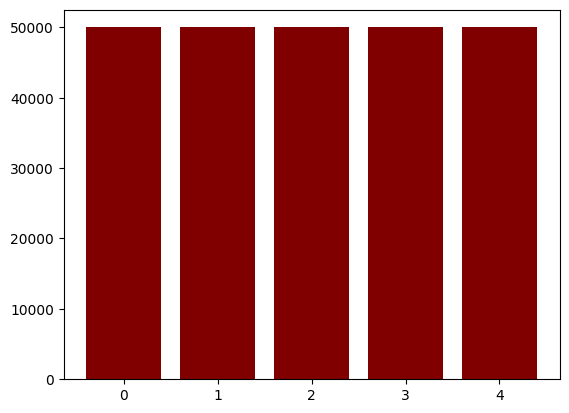

In [58]:
# blanced training data graph ploting
train_data_r = pd.DataFrame(train_data_resampled)
class_data = train_data_r[300].value_counts()
print(class_data)
plt.bar(class_data.index, class_data.values, color ='maroon')
plt.show()

# save balanced training data
file_name = project_path + 'train_data_SMOTE.pkl'
train_data_r.to_pickle(file_name)

In [59]:
data_bal = np.array(class_data)
data_bal2 = data_bal.reshape(1, 5)

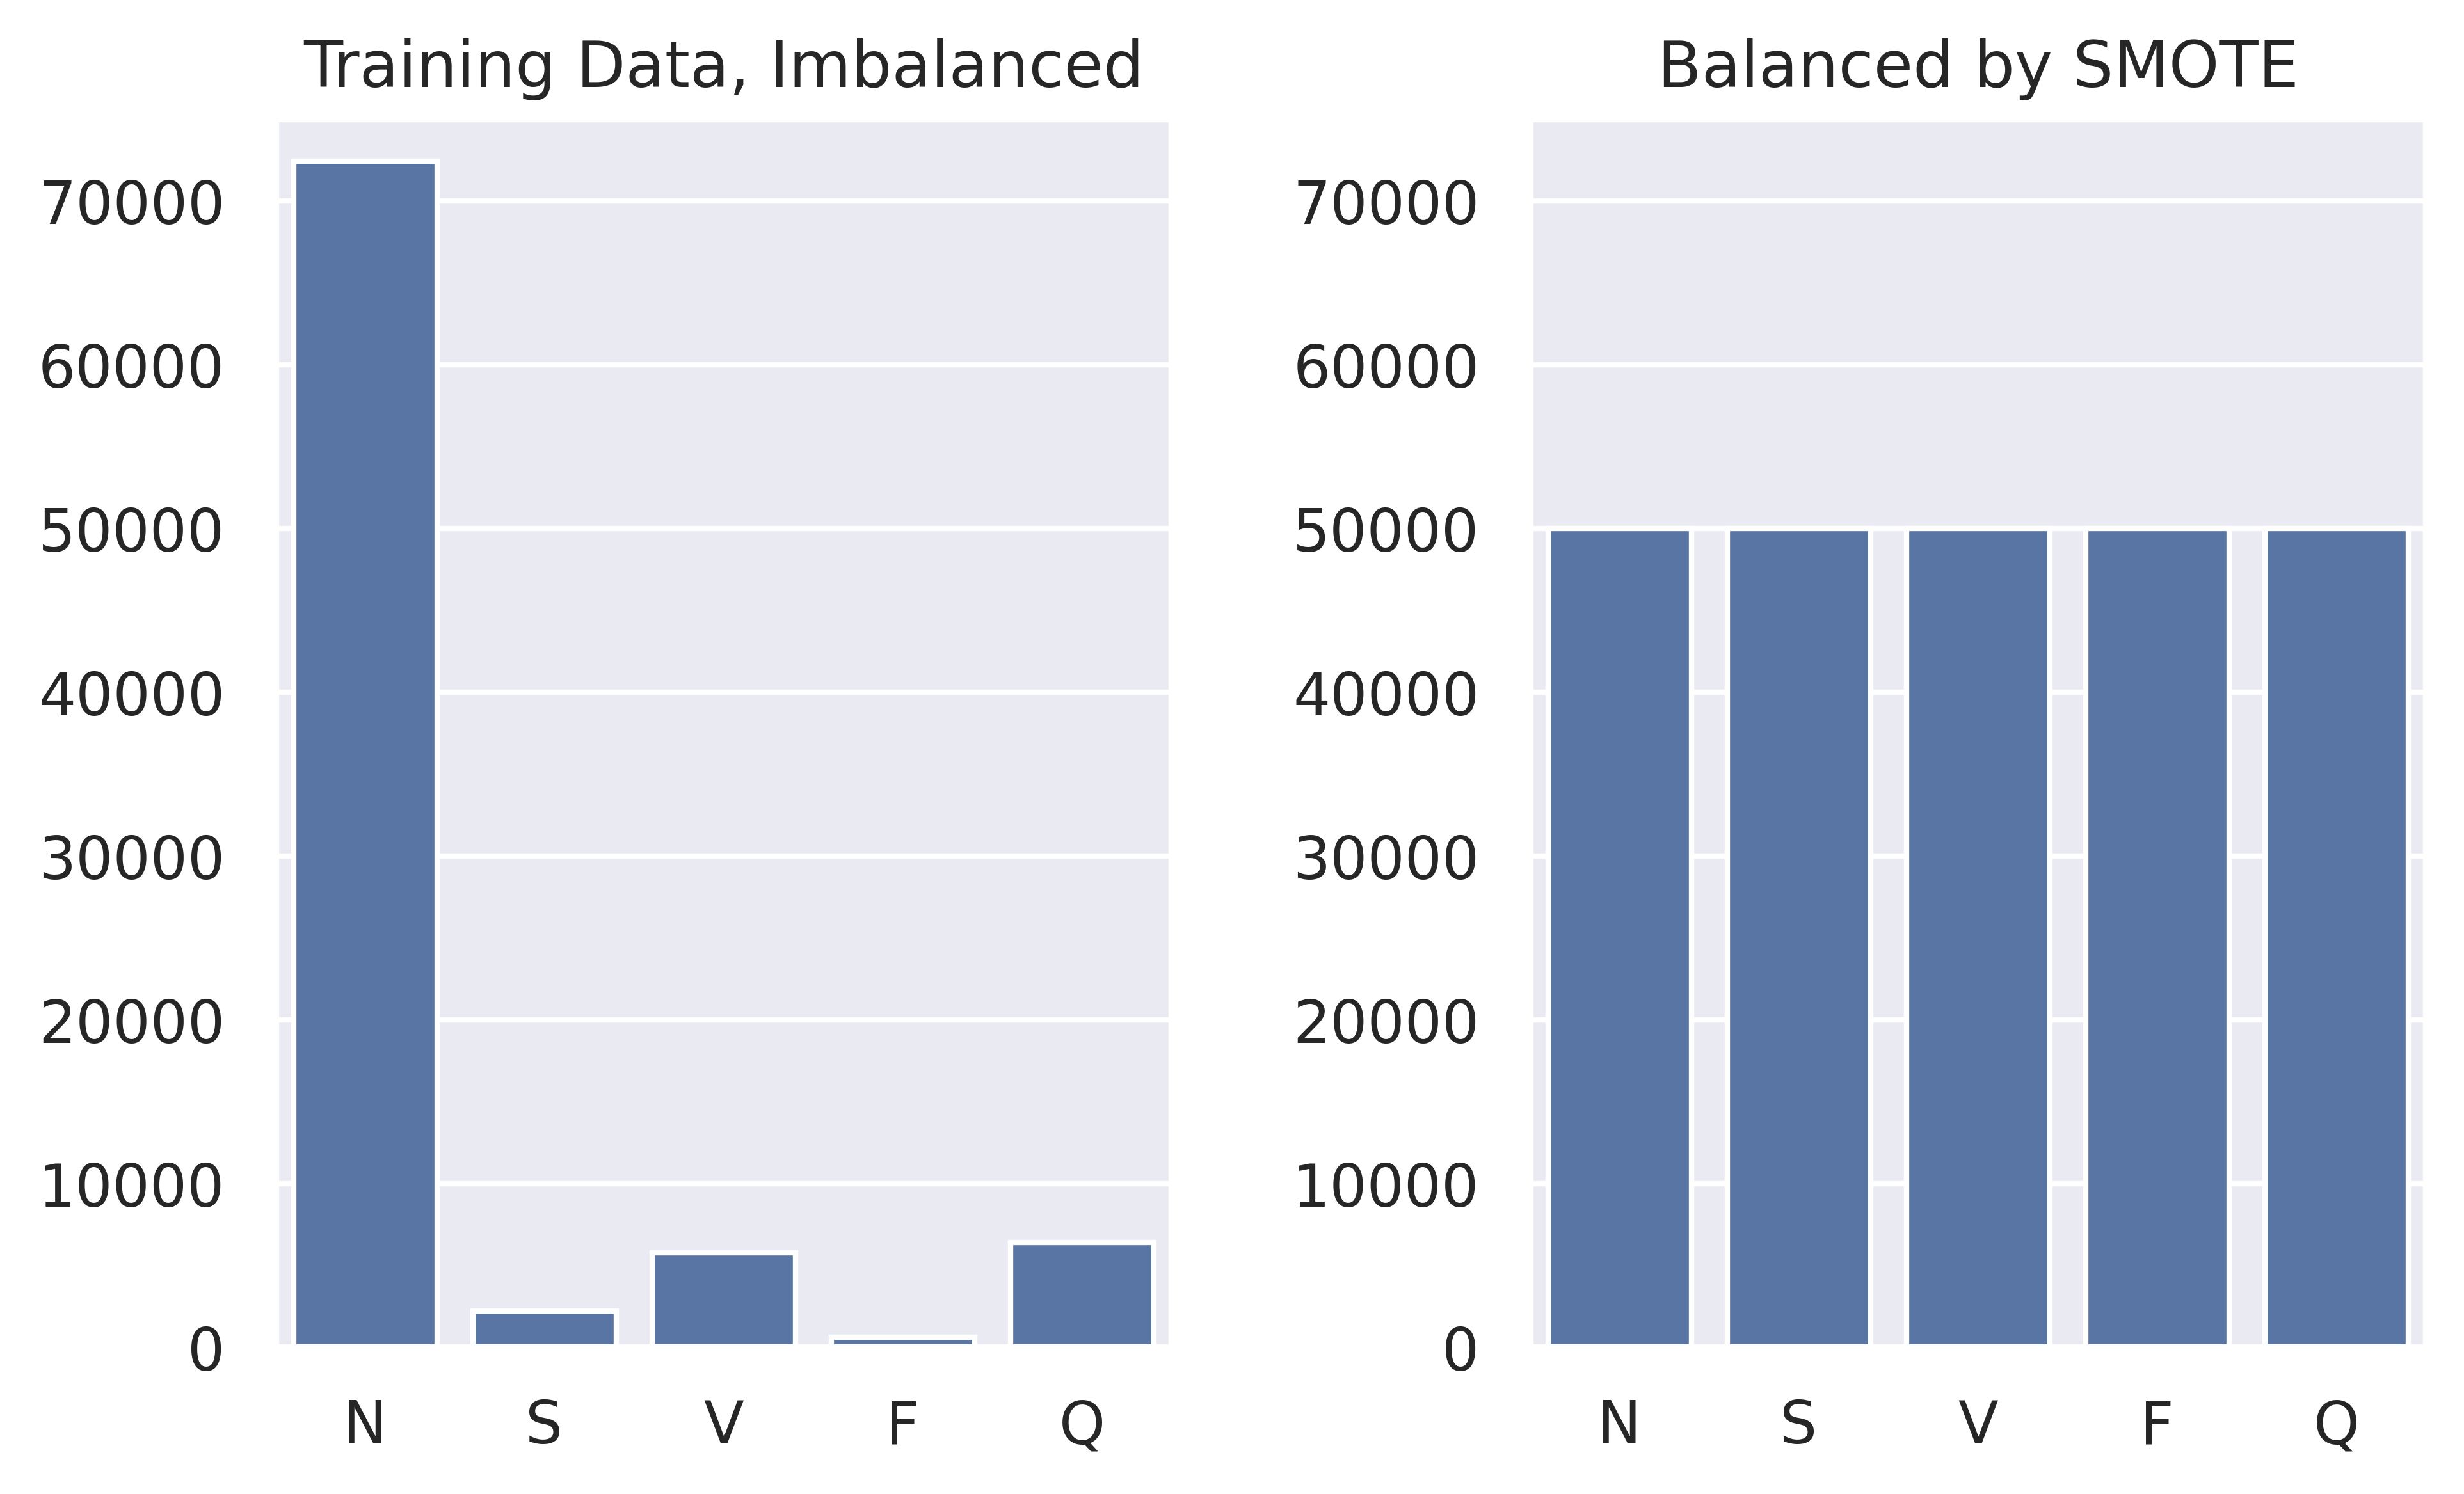

In [60]:
# a single plot which gives proper illustration before and after class balancing
import seaborn as sns
sns.set()
sns.color_palette("hls", 8)

fig = plt.figure(figsize=(7,4), dpi=600)
plt.subplot(121)
sns.barplot(x = ['N', 'S', 'V', 'F', 'Q'], y = [72420, 2212, 5774, 637, 6401])
plt.ylim(0, 75000)
plt.title('Training Data, Imbalanced')

plt.subplot(122)
sns.barplot(x = ['N', 'S', 'V', 'F', 'Q'], y = class_data.values)
plt.ylim(0, 75000)
plt.title('Balanced by SMOTE')

plt.subplots_adjust(left=0.1,
                    bottom=0.1,
                    right=0.9,
                    top=0.9,
                    wspace=0.4,
                    hspace=0.5)

fig.savefig(FIG_DIR + "Class_balancing.png")

# **Part E: Model Building and Training**
A **CNN-LSTM and attention** based hybrid model is formulated.

## **E1: Attention Mechanism**
**Convolutional Block Attention Module** ([CBAM](https://arxiv.org/abs/1807.06521)) consists two parts (i) **channel attention**, (ii) spatial attention. ECG is an 1D signal and 1-lead ECG is used in the modle.Therefore, only channel attention is only used.

In [61]:
class ChannelAttention(tf.keras.layers.Layer):

    def __init__(self, filters, ratio=8):
        super(ChannelAttention, self).__init__()
        self.filters = filters
        self.ratio = ratio

    def build(self, input_shape):

        self.shared_layer_one = tf.keras.layers.Dense(
            self.filters // self.ratio,
            activation="relu",
            kernel_initializer="he_normal",
            use_bias=True
        )

        self.shared_layer_two = tf.keras.layers.Dense(
            self.filters,
            kernel_initializer="he_normal",
            use_bias=True
        )

    def call(self, inputs):

        avg_pool = tf.keras.layers.GlobalAveragePooling1D()(inputs)
        avg_pool = self.shared_layer_one(avg_pool)
        avg_pool = self.shared_layer_two(avg_pool)

        max_pool = tf.keras.layers.GlobalMaxPooling1D()(inputs)
        max_pool = self.shared_layer_one(max_pool)
        max_pool = self.shared_layer_two(max_pool)

        attention = tf.keras.layers.Add()([avg_pool, max_pool])
        attention = tf.keras.layers.Activation("sigmoid")(attention)

        attention = tf.keras.layers.Reshape((1, self.filters))(attention)

        return inputs * attention

In [62]:
# udf for spatial attention mechanism
class SpatialAttention(tf.keras.layers.Layer):
      def __init__(self, kernel_size):
        super(SpatialAttention, self).__init__()
        self.kernel_size = kernel_size

        def build(self, input_shape):
            self.conv2d = tf.keras.layers.Conv2D(filters = 1,
                    kernel_size=self.kernel_size,
                    strides=1,
                    padding='same',
                    activation='sigmoid',
                    kernel_initializer='he_normal',
                    use_bias=False)

        def call(self, inputs):

            # AvgPool
            avg_pool = tf.keras.layers.Lambda(lambda x: tf.keras.backend.mean(x, axis=3, keepdims=True))(inputs)

            # MaxPool
            max_pool = tf.keras.layers.Lambda(lambda x: tf.keras.backend.max(x, axis=3, keepdims=True))(inputs)

            attention = tf.keras.layers.Concatenate(axis=3)([avg_pool, max_pool])

            attention = self.conv2d(attention)


            return tf.keras.layers.multiply([inputs, attention])

## **E2: CNN-LSTM and attention model architecture**

### **a. Model building**

In [63]:
# Build a CNN model
def buildModel():
    newModel = tf.keras.models.Sequential([
        tf.keras.layers.InputLayer(input_shape=(300, 1)),
        # The first convolutional layer, sixteen 21x1 convolution kernels
        tf.keras.layers.Conv1D(filters=16, kernel_size=21, strides=1, padding='same', activation='relu'),
        ChannelAttention(16, 8),
        # SpatialAttention(7),
        # The first pooling layer, max pooling, 3x1 convolution kernels, stride 2
        tf.keras.layers.MaxPool1D(pool_size=3, strides=2, padding='same'),
        # The second convolution layer, 32 23x1 convolution kernels
        tf.keras.layers.Conv1D(filters=32, kernel_size=23, strides=1, padding='same', activation='relu'),
        ChannelAttention(32, 8),
        # SpatialAttention(7),
        # The second pooling layer, max pooling, 3x1 convolution kernels, with a stride of 2
        tf.keras.layers.MaxPool1D(pool_size=3, strides=2, padding='same'),
        # The third convolution layer, 64 25x1 convolution kernels
        tf.keras.layers.Conv1D(filters=64, kernel_size=25, strides=1, padding='same', activation='relu'),
        ChannelAttention(64, 8),
        # SpatialAttention(7),
        # The third pooling layer, average pooling, 3x1 convolution kernels, stride 2
        tf.keras.layers.AvgPool1D(pool_size=3, strides=2, padding='same'),
        # The fourth convolution layer, 128 27x1 convolution kernels
        tf.keras.layers.Conv1D(filters=128, kernel_size=27, strides=1, padding='same', activation='relu'),
        ChannelAttention(128, 8),
        SpatialAttention(7),
        # LSTM layer, 64 nodes
        tf.keras.layers.LSTM(64, return_sequences=True),
        # Dropout layer,dropout = 0.2
        tf.keras.layers.Dropout(rate=0.2),
        # LSTM layer, 32 nodes
        tf.keras.layers.LSTM(32, return_sequences=True),
        # Flatten the layer to facilitate the processing of the fully connected layer
        tf.keras.layers.Flatten(),
        # Fully connected layer, 128 nodes
        tf.keras.layers.Dense(128, activation='relu'),
        # Dropout layer,dropout = 0.2
        tf.keras.layers.Dropout(rate=0.2),
        # Fully connected layer, 5 nodes
        tf.keras.layers.Dense(5, activation='softmax')
    ])
    return newModel

### **b. Hyperparameter Tuning**
Many architectures of model is found by changing hyperparameters.
* Model: with or without channel or spatial attention.
* CNN Filters: Number of filters in each Conv layer is changing like 4, 16, 32, 64, 128 etc.
* LSTM Units: Number of units of two LSTM layer is varing like 32, 64, 128 etc.

In [64]:
# Build a CNN model
def buildModel():
    newModel = tf.keras.models.Sequential([
        tf.keras.layers.InputLayer(input_shape=(300, 1)),
        # The first convolutional layer, four 21x1 convolution kernels
        tf.keras.layers.Conv1D(filters=16, kernel_size=21, strides=1, padding='same', activation='relu'),
        # The first pooling layer, max pooling, four 3x1 convolution kernels, stride 2
        tf.keras.layers.MaxPool1D(pool_size=3, strides=2, padding='same'),
        # The second convolution layer, 16 23x1 convolution kernels
        tf.keras.layers.Conv1D(filters=32, kernel_size=23, strides=1, padding='same', activation='relu'),
        # The second pooling layer, max pooling, four 3x1 convolution kernels, with a stride of 2
        tf.keras.layers.MaxPool1D(pool_size=3, strides=2, padding='same'),
        # The third convolution layer, 32 25x1 convolution kernels
        tf.keras.layers.Conv1D(filters=64, kernel_size=25, strides=1, padding='same', activation='relu'),
        # The third pooling layer, average pooling, four 3x1 convolution kernels, stride 2
        tf.keras.layers.AvgPool1D(pool_size=3, strides=2, padding='same'),
        # The fourth convolution layer, 64 27x1 convolution kernels
        tf.keras.layers.Conv1D(filters=128, kernel_size=27, strides=1, padding='same', activation='relu'),
        # LSTM layer, 64 nodes
        tf.keras.layers.LSTM(128, return_sequences=True),
        # Dropout layer,dropout = 0.2
        tf.keras.layers.Dropout(rate=0.2),
        # LSTM layer, 64 nodes
        tf.keras.layers.LSTM(64, return_sequences=True),
        # Flatten the layer to facilitate the processing of the fully connected layer
        tf.keras.layers.Flatten(),
        # Fully connected layer, 128 nodes
        tf.keras.layers.Dense(128, activation='relu'),
        # Dropout layer,dropout = 0.2
        tf.keras.layers.Dropout(rate=0.2),
        # Fully connected layer, 5 nodes
        tf.keras.layers.Dense(5, activation='softmax')
    ])
    return newModel

### **c. Model Training**

**Build, save and then Fit the Model.**
If we have already the saved model, then no need to build, save and fit again.

In [65]:
# Reshape for CNN/LSTM input
X_train = x_train.reshape(-1, 300, 1)
X_test  = x_test.reshape(-1, 300, 1)

Y_train = y_train
Y_test  = y_test

print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)

X_train shape: (87444, 300, 1)
Y_train shape: (87444, 1)


In [66]:
# TensorBoard log directory (can stay local)
logdir = os.path.join(
    project_path,
    "logs",
    datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
)

# Validation ratio
ratio = 0.2


# Load or Train Model

if os.path.exists(MODEL_PATH):

    print("Loading model from Google Drive...")
    model = tf.keras.models.load_model(MODEL_PATH)
    history = None

else:

    print("No saved model found. Training model...")

    model = buildModel()

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.summary()


    # TensorBoard
    tensorboard_callback = tf.keras.callbacks.TensorBoard(
        log_dir=logdir,
        histogram_freq=1
    )


    # Best-weights checkpoint
    checkpoint_filepath = MODEL_DIR + "/best_weights.weights.h5"

    model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_filepath,
        save_weights_only=True,
        monitor='val_accuracy',
        mode='max',
        save_best_only=True
    )


    callbacks = [
        tensorboard_callback,
        model_checkpoint_callback
    ]


    # Train
    history = model.fit(
        X_train,
        Y_train,
        epochs=30,
        batch_size=128,
        validation_split=ratio,
        callbacks=callbacks
    )


    # Save permanently to Drive
    model.save(MODEL_PATH)

    print("Model saved to Google Drive.")


No saved model found. Training model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 300, 16)        │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 150, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 150, 32)        │        11,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 75, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 75, 64)         │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d               │ (None, 38, 64)         │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 38, 128)        │       221,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 38, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 38, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 38, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2432)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       311,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 777,797 (2.97 MB)

 Trainable params: 777,797 (2.97 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 241s 433ms/step - accuracy: 0.8914 - loss: 0.4010 - val_accuracy: 0.9751 - val_loss: 0.0983
Epoch 2/30
135/547 ━━━━━━━━━━━━━━━━━━━━ 2:37 382ms/step - accuracy: 0.9756 - loss: 0.0963

KeyboardInterrupt: 

### **d. Plotting Accuracy and Loss**
Training and Validation accuray and loss curve plotting.

In [ ]:
# plot accuracy during training
if history is not None:

    plt.title('Accuracy')
    plt.plot(history.history['accuracy'], label='train accuracy')
    plt.plot(history.history['val_accuracy'], label='val accuracy')
    plt.legend()
    plt.show()

    plt.title('Loss')
    plt.plot(history.history['loss'], label='train loss')
    plt.plot(history.history['val_loss'], label='val loss')
    plt.legend()
    plt.show()

else:
    print("Model loaded from Drive — no training history available.")

In [ ]:
# Load the TensorBoard notebook extension
%load_ext tensorboard
%tensorboard --logdir "/content/data/mitdb/logs\20260205-103804"

# **Part F: Results**


## **F1: Classification Accuracy and Confusion Matrix**
The overall classification accuracy and confusion matrix generated by the follwoing code.

**Model Testing**
* a. Using **recently trained** and Saved Model after 30 Epochs.
* b. Using the **best model** saved by *'model checkpoint'* callback.

**a. Using Recently Trained Model**

In [ ]:
# evaluate the model
train_loss, train_acc = model.evaluate(X_train, Y_train, verbose=0)
test_loss, test_acc = model.evaluate(X_test, Y_test, verbose=0)
print('Training Accuracy: %.2f, Test Accuracy: %.2f' % (train_acc*100, test_acc*100))
print('Training Loss: %.2f, Test Loss: %.2f' % (train_loss*100, test_loss*100))

**b. Using the Best Model**
We saved many checkpoints of the model. Among these checkpoints we will consider the checkpoint which has the largest validation accuracy. Then copy its path and update the model weights.

In [ ]:
# ==========================================
# Load Trained ECG Model (Safe Version)
# ==========================================

import os
import tensorflow as tf


# Google Drive paths
MODEL_PATH = "/content/drive/MyDrive/ecg_model/ecg_model.keras"
CHECKPOINT_PATH = "/content/drive/MyDrive/ecg_model/best_weights.weights.h5"


# -------------------------------
# Priority 1: Load full model
# -------------------------------

if os.path.exists(MODEL_PATH):

    print("Loading full model from Drive...")

    model = tf.keras.models.load_model(MODEL_PATH)

    print("Full model loaded.")


# -------------------------------
# Priority 2: Fallback to weights
# -------------------------------

elif os.path.exists(CHECKPOINT_PATH):

    print("Full model not found. Loading from checkpoint weights...")

    model = buildModel()

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    model.load_weights(CHECKPOINT_PATH)

    print("Checkpoint weights loaded.")


# -------------------------------
# Priority 3: Train (last resort)
# -------------------------------

else:

    print("No saved model found. Training from scratch...")

    model = buildModel()

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train,
        Y_train,
        epochs=30,
        batch_size=128,
        validation_split=0.2
    )

    model.save(MODEL_PATH)

    print("Model trained and saved.")


# -------------------------------
# Verify
# -------------------------------

model.summary()


In [ ]:
# train_loss_cp, train_acc_cp = model2.evaluate(X_train, Y_train, verbose=0)
# test_loss_cp, test_acc_cp = model2.evaluate(X_test, Y_test, verbose=0)
# print('Training Accuracy: %.2f, Test Accuracy: %.2f' % (train_acc_cp*100, test_acc_cp*100))
# print('Training Loss: %.2f, Test Loss: %.2f' % (train_loss_cp*100, test_loss_cp*100))
# Fast evaluation of best model (use large batch size)

# ==========================================
# Evaluate Loaded Model (Production Model)
# ==========================================

# Evaluate on TEST set only
test_loss, test_acc = model.evaluate(
    X_test,
    Y_test,
    batch_size=256,
    verbose=1
)

print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


**Confusion Matrix**

In [ ]:
# confusion matrix
def plotHeatMap(Y_test, Y_pred):

    con_mat = confusion_matrix(Y_test, Y_pred)

    plt.figure(figsize=(8,8))

    seaborn.heatmap(
        con_mat,
        annot=True,
        square=True,
        fmt='d',
        cmap='Greens'
    )

    plt.xlabel("Predicted")
    plt.ylabel("True")

    plt.tight_layout()

    plt.savefig(FIG_DIR + "confusion_matrix.pdf")

    plt.show()

In [ ]:
# predict
Y_pred = np.argmax(model.predict(X_test), axis=-1)
# Y_pred = model.predict_classes(X_test)
# plot confusion matrix
plotHeatMap(Y_test, Y_pred)

## **F2: Per Class Performance**
Calculating per class Sensitivity, Specificity, Accuracy and F1 score.

In [ ]:
# Per class accuracy printing function
def _report(TN, FP, FN, TP):
    TPR = TP/(TP+FN) if (TP+FN)!=0 else 0
    TNR = TN/(TN+FP) if (TN+FP)!=0 else 0
    PPV = TP/(TP+FP) if (TP+FP)!=0 else 0
    '''
    report = {'TP': TP, 'TN': TN, 'FP': FP, 'FN': FN,
              'TPR': TPR, 'Recall': TPR, 'Sensitivity': TPR,
              'TNR' : TNR, 'Specificity': TNR,
              'FPR': FP/(FP+TN) if (FP+TN)!=0 else 0,
              'FNR': FN/(FN+TP) if (FN+TP)!=0 else 0,
              'PPV': PPV, 'Precision': PPV,
              'F1 Score': 2*(PPV*TPR)/(PPV+TPR),
              'Per Class Accuracy': (TP+TN)/(TP+FP+FN+TN)
             }'''

    report = {'Sensitivity (%)': TPR*100,
              'Specificity (%)': TNR*100,
              'F1 Score (%)': 2*100*(PPV*TPR)/(PPV+TPR),
              'Per Class Accuracy (%)': (TP+TN)*100/(TP+FP+FN+TN)
             }
    return report

def multi_classification_report(y_test, y_pred, labels=None, encoded_labels=True, as_frame=False):
    """
    Args:
        y_test (ndarray)
        y_pred (ndarray)
        labels (list)
        encoded_labels (bool): Need to be False if labels are not one hot encoded
        as_fram (bool): If True, return type will be DataFrame

    Return:
        report (dict)
    """

    import numpy as np
    import pandas as pd
    from sklearn.metrics import multilabel_confusion_matrix

    conf_labels = None if encoded_labels else labels

    conf_mat = multilabel_confusion_matrix(y_test, y_pred, labels=conf_labels)
    report = dict()
    if labels == None:
        counter = np.arange(len(conf_mat))
    else:
        counter = labels

    for i, name in enumerate(counter):
        TN, FP, FN, TP = conf_mat[i].ravel()
        report[name] = _report(TN, FP, FN, TP)

    if as_frame:
        return pd.DataFrame(report)
    return report

**a. Recently Trained Model**

In [ ]:
# Per class performance
labels = ['N', 'S', 'V', 'F', 'Q']
Y_pred = np.argmax(model.predict(X_test), axis=-1)
multi_classification_report(Y_test, Y_pred, labels=labels, encoded_labels=True, as_frame=True)

**b. Best Model**

In [ ]:
# Per class performance
# Per class performance (Loaded Production Model)
labels = ['N', 'S', 'V', 'F', 'Q']

Y_pred = np.argmax(model.predict(X_test), axis=-1)

multi_classification_report(
    Y_test,
    Y_pred,
    labels=labels,
    encoded_labels=True,
    as_frame=True
)

## **F3: Interactive Patient ECG Viewer**


In [ ]:
# ==========================================
# F3 — Interactive ECG Viewer (Final Version)
# ==========================================

import wfdb
import neurokit2 as nk
import plotly.graph_objects as go
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import warnings


# -------------------------------
# Suppress Pandas / NeuroKit noise
# -------------------------------

warnings.filterwarnings("ignore", message=".*ChainedAssignment.*")
warnings.filterwarnings("ignore", message=".*copy of a DataFrame.*")


# -------------------------------
# Load example patient
# -------------------------------

record = wfdb.rdrecord(project_path + "100", channel_names=["MLII"])
data = record.p_signal.flatten()


# -------------------------------
# Denoise (your existing function)
# -------------------------------

rdata = denoise(data)


# -------------------------------
# Normalise (improves detection)
# -------------------------------

scaler = MinMaxScaler()
rdata = scaler.fit_transform(
    rdata.reshape(-1, 1)
).flatten()


# -------------------------------
# Trim to first 30s (speed)
# -------------------------------

fs = 360
duration = 30  # seconds

rdata = rdata[: fs * duration]


# -------------------------------
# NeuroKit Processing
# -------------------------------

signals, info = nk.ecg_process(
    rdata,
    sampling_rate=fs,
    method="neurokit"
)


# Convert to NumPy (safe for Pandas 3.x)
p_peaks = signals["ECG_P_Peaks"].to_numpy()
r_peaks = signals["ECG_R_Peaks"].to_numpy()
t_peaks = signals["ECG_T_Peaks"].to_numpy()


# -------------------------------
# Time axis
# -------------------------------

time = np.arange(len(rdata)) / fs


# -------------------------------
# Interactive Plot
# -------------------------------

fig = go.Figure()


# ECG waveform
fig.add_trace(
    go.Scatter(
        x=time,
        y=rdata,
        name="ECG",
        line=dict(color="black", width=1),
        hovertemplate="Time: %{x:.2f}s<br>Voltage: %{y:.3f}"
    )
)


# P waves
fig.add_trace(
    go.Scatter(
        x=time[p_peaks == 1],
        y=rdata[p_peaks == 1],
        mode="markers",
        name="P wave",
        marker=dict(size=6, color="blue")
    )
)


# R peaks
fig.add_trace(
    go.Scatter(
        x=time[r_peaks == 1],
        y=rdata[r_peaks == 1],
        mode="markers",
        name="R peak",
        marker=dict(size=8, color="green")
    )
)


# T waves
fig.add_trace(
    go.Scatter(
        x=time[t_peaks == 1],
        y=rdata[t_peaks == 1],
        mode="markers",
        name="T wave",
        marker=dict(size=6, color="orange")
    )
)


# -------------------------------
# Layout
# -------------------------------

fig.update_layout(
    title="Interactive ECG With P/QRS/T Annotations",
    xaxis_title="Time (seconds)",
    yaxis_title="Normalised Voltage",
    template="simple_white",
    height=600,
    legend=dict(orientation="h"),
    hovermode="x unified"
)


# -------------------------------
# Save for GitHub / Dissertation
# -------------------------------

# Save interactive version (works everywhere)
fig.write_html(
    "/content/drive/MyDrive/ecg_model/ecg_viewer.html"
)

print("Saved interactive ECG viewer to Google Drive.")


# -------------------------------
# Show in Colab
# -------------------------------

fig.show()

In [ ]:
# ==========================================
# Export classifier metrics
# ==========================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

accuracy = accuracy_score(Y_test, Y_pred)
precision = precision_score(Y_test, Y_pred, average="macro")
recall = recall_score(Y_test, Y_pred, average="macro")
f1 = f1_score(Y_test, Y_pred, average="macro")

probs = model.predict(X_test)
roc_auc = roc_auc_score(Y_test, probs, multi_class="ovr")

metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "ECE"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        ece_cal
    ]
})

metrics.to_latex(TAB_DIR + "/model_metrics.tex", index=False)

metrics

# **Part G: Calibration (temperature scaling + ECE)**


In [ ]:
# ==========================================
# Part G: Calibration (Temperature Scaling + ECE)
# ==========================================

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from scipy.optimize import minimize
from sklearn.model_selection import train_test_split


# -------------------------------------------------
# Step 1 — Create calibration split
# -------------------------------------------------

X_fit, X_cal, y_fit, y_cal = train_test_split(
    X_train,
    Y_train,
    test_size=0.2,
    stratify=Y_train,
    random_state=42
)

print("Calibration set size:", X_cal.shape)


# -------------------------------------------------
# Step 2 — Ensure model graph exists
# -------------------------------------------------

_ = model.predict(X_train[:1], verbose=0)


# -------------------------------------------------
# Step 3 — Build a proper logits model
# IMPORTANT:
# We want the output of the final Dense(5) layer
# BEFORE softmax, not the 128-d penultimate features.
# -------------------------------------------------

final_dense = model.layers[-1]

# Recreate the final Dense layer without activation
logits_output = tf.keras.layers.Dense(
    units=final_dense.units,
    activation=None,
    use_bias=True,
    name="logits_layer"
)(model.layers[-2].output)

logits_model = Model(
    inputs=model.inputs,
    outputs=logits_output
)

# Copy weights from the trained final classification layer
logits_model.get_layer("logits_layer").set_weights(final_dense.get_weights())

print("Logits model created")


def get_logits(x):
    x = np.asarray(x).astype(np.float32)
    return logits_model.predict(x, batch_size=256, verbose=0)


# -------------------------------------------------
# Step 4 — Prepare calibration labels
# -------------------------------------------------

labels_cal = y_cal.astype(int).flatten()


# -------------------------------------------------
# Step 5 — Temperature scaling objective
# -------------------------------------------------

def temperature_scale(T, logits, labels):

    T = float(T[0])

    logits_T = logits / T

    # numerically stable softmax
    exp = np.exp(logits_T - np.max(logits_T, axis=1, keepdims=True))
    probs = exp / np.sum(exp, axis=1, keepdims=True)

    nll = -np.log(
        probs[np.arange(len(labels)), labels] + 1e-12
    )

    return np.mean(nll)


# -------------------------------------------------
# Step 6 — Compute logits on calibration set
# -------------------------------------------------

logits_val = get_logits(X_cal)


# -------------------------------------------------
# Step 7 — Optimise temperature
# -------------------------------------------------

opt = minimize(
    temperature_scale,
    x0=[1.0],
    args=(logits_val, labels_cal),
    bounds=[(0.05, 10.0)]
)

T_star = float(opt.x[0])

print("Optimal Temperature:", T_star)


# -------------------------------------------------
# Step 8 — Calibrated probability prediction
# -------------------------------------------------

def predict_proba_calibrated(x):

    logits = get_logits(x)
    logits = logits / T_star

    exp = np.exp(logits - np.max(logits, axis=1, keepdims=True))
    probs = exp / np.sum(exp, axis=1, keepdims=True)

    return probs


# -------------------------------------------------
# Step 9 — Expected Calibration Error (ECE)
# -------------------------------------------------

def compute_ece(probs, labels, n_bins=15):

    labels = labels.astype(int).flatten()

    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    accuracy = (predictions == labels)

    bins = np.linspace(0.0, 1.0, n_bins + 1)

    ece = 0.0

    for i in range(n_bins):

        if i == n_bins - 1:
            mask = (confidences >= bins[i]) & (confidences <= bins[i+1])
        else:
            mask = (confidences >= bins[i]) & (confidences < bins[i+1])

        if np.sum(mask) > 0:
            acc_bin = np.mean(accuracy[mask])
            conf_bin = np.mean(confidences[mask])
            ece += np.abs(acc_bin - conf_bin) * np.sum(mask) / len(labels)

    return ece


# -------------------------------------------------
# Step 10 — Evaluate calibration
# -------------------------------------------------

labels_test = y_test.astype(int).flatten()

probs_uncal = model.predict(X_test, batch_size=256, verbose=0)
probs_cal = predict_proba_calibrated(X_test)

ece_uncal = compute_ece(probs_uncal, labels_test)
ece_cal = compute_ece(probs_cal, labels_test)

print("ECE before calibration:", ece_uncal)
print("ECE after calibration:", ece_cal)


# -------------------------------------------------
# Step 11 — Sanity checks
# -------------------------------------------------

print("Uncalibrated probs shape:", probs_uncal.shape)
print("Calibrated probs shape:", probs_cal.shape)

print("First 10 uncalibrated preds:", np.argmax(probs_uncal[:10], axis=1))
print("First 10 calibrated preds:", np.argmax(probs_cal[:10], axis=1))
print("First 10 true labels:", labels_test[:10])

clean_acc_uncal = np.mean(np.argmax(probs_uncal, axis=1) == labels_test)
clean_acc_cal = np.mean(np.argmax(probs_cal, axis=1) == labels_test)

print("Clean accuracy before calibration:", clean_acc_uncal)
print("Clean accuracy after calibration:", clean_acc_cal)



In [ ]:
import matplotlib.pyplot as plt

def reliability_diagram(probs, labels, bins=10):

    conf = np.max(probs, axis=1)
    preds = np.argmax(probs, axis=1)

    acc = preds == labels

    bin_edges = np.linspace(0, 1, bins + 1)

    acc_bin = []
    conf_bin = []

    for i in range(bins):

        if i == bins - 1:
            mask = (conf >= bin_edges[i]) & (conf <= bin_edges[i+1])
        else:
            mask = (conf >= bin_edges[i]) & (conf < bin_edges[i+1])

        if np.sum(mask) > 0:
            acc_bin.append(np.mean(acc[mask]))
            conf_bin.append(np.mean(conf[mask]))

    plt.figure(figsize=(6, 6))
    plt.plot(conf_bin, acc_bin, marker='o', label='Model')
    plt.plot([0, 1], [0, 1], '--', label='Perfect calibration')

    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.title("Reliability Diagram")
    plt.legend()

    plt.tight_layout()
    plt.savefig(FIG_DIR + "reliability_diagram.pdf")
    plt.show()


# run it after probs_cal and labels_test already exist
reliability_diagram(probs_cal, labels_test)

# **Part H: Conformal Prediction (Uncertainty Sets)**


In [ ]:
# ==========================================
# Part H: Conformal Prediction (Uncertainty Sets)
# ==========================================

import numpy as np
from sklearn.model_selection import train_test_split


# -------------------------------------------------
# Step 1 — Conformal Coverage Level
# -------------------------------------------------

alpha = 0.1   # 90% coverage


# -------------------------------------------------
# Step 2 — Calibration Split
# (separate from test set)
# -------------------------------------------------

X_fit, X_cal, y_fit, y_cal = train_test_split(
    X_train,
    Y_train,
    test_size=0.2,
    stratify=Y_train,
    random_state=42
)

print("Calibration set size:", X_cal.shape)


# -------------------------------------------------
# Step 3 — Ensure label format
# -------------------------------------------------

labels_cal = y_cal.astype(int).flatten()


# -------------------------------------------------
# Step 4 — Compute calibrated probabilities
# -------------------------------------------------

cal_probs = predict_proba_calibrated(X_cal)


# -------------------------------------------------
# Step 5 — Nonconformity Scores
# (1 − probability of true class)
# -------------------------------------------------

scores = 1 - cal_probs[
    np.arange(len(labels_cal)),
    labels_cal
]


# -------------------------------------------------
# Step 6 — Conformal Quantile Threshold
# -------------------------------------------------

qhat = np.quantile(scores, 1 - alpha)

print("Conformal threshold qhat:", qhat)


# -------------------------------------------------
# Step 7 — Conformal Prediction Set Function
# -------------------------------------------------

def conformal_prediction_set(x):

    probs = predict_proba_calibrated(x)

    prediction_sets = []

    for p in probs:

        scores = 1 - p

        indices = np.where(scores <= qhat)[0]

        # safety: ensure non-empty set
        if len(indices) == 0:
            indices = np.array([np.argmax(p)])

        prediction_sets.append(indices)

    return prediction_sets


# -------------------------------------------------
# Step 8 — Example Usage
# -------------------------------------------------

example_sets = conformal_prediction_set(X_test[:10])

for i, s in enumerate(example_sets):
    print(f"Sample {i} prediction set:", s)

# **Part I: Grad-CAM Explainability**

In [ ]:
# ==========================================
# Part I: Explainability — Gradient Saliency
# ==========================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


# -------------------------------------------------
# Step 1 — Ensure model graph exists
# -------------------------------------------------

_ = model.predict(X_train[:1], verbose=0)


# -------------------------------------------------
# Step 2 — Saliency computation
# -------------------------------------------------

def saliency_1d(signal):

    signal = np.array(signal)

    # Ensure correct shape (1,300,1)
    if signal.ndim == 1:
        signal = signal.reshape(1,300,1)
    elif signal.ndim == 2:
        signal = signal[np.newaxis,:,:]

    signal = tf.convert_to_tensor(signal, dtype=tf.float32)

    with tf.GradientTape() as tape:

        tape.watch(signal)

        preds = model(signal, training=False)

        class_idx = tf.argmax(preds[0])

        loss = preds[:, class_idx]

    grads = tape.gradient(loss, signal)

    if grads is None:
        raise RuntimeError("Gradient computation failed.")

    saliency = tf.abs(grads)[0,:,0].numpy()

    # Normalise
    saliency = saliency / (np.max(saliency) + 1e-8)

    return saliency


# -------------------------------------------------
# Step 3 — ECG + Saliency visualisation
# -------------------------------------------------

def plot_ecg_saliency(ecg, saliency):

    ecg = ecg.flatten()
    saliency = saliency / (np.max(saliency) + 1e-8)

    t = np.arange(len(ecg))

    fig, ax = plt.subplots(figsize=(12,4))

    # Draw saliency heatmap background
    ax.imshow(
        saliency[np.newaxis,:],
        cmap="hot",
        aspect="auto",
        extent=[0, len(ecg), min(ecg), max(ecg)],
        alpha=0.6
    )

    # Draw ECG waveform on top
    ax.plot(t, ecg, color="black", linewidth=1.5)

    ax.set_title("ECG with Saliency Explanation")
    ax.set_xlabel("Sample")
    ax.set_ylabel("Amplitude")

plt.tight_layout()
plt.savefig(FIG_DIR + "gradcam_ecg_example.pdf")
plt.show()


# -------------------------------------------------
# Step 4 — Example usage
# -------------------------------------------------

sample = X_test[0]

saliency_map = saliency_1d(sample)

print("Saliency map shape:", saliency_map.shape)

plot_ecg_saliency(sample, saliency_map)

# **Part J: Prototype Retrieval (Example Explanations)**

In [ ]:
# ==========================================================
# Part J: Prototype Retrieval (Example-Based Explanations)
# ==========================================================

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics.pairwise import euclidean_distances
import matplotlib.pyplot as plt


# ----------------------------------------------------------
# Step 1 — Ensure model graph exists
# ----------------------------------------------------------

_ = model(X_train[:1], training=False)


# ----------------------------------------------------------
# Step 2 — Build embedding model
# (penultimate representation of classifier)
# ----------------------------------------------------------

EMBED_LAYER_INDEX = -2

embedding_model = Model(
    inputs=model.inputs,
    outputs=model.layers[EMBED_LAYER_INDEX].output
)

print("Embedding dimension:", embedding_model.output_shape)


# ----------------------------------------------------------
# Step 3 — Build prototype bank
# ----------------------------------------------------------

PROTOTYPE_BANK_SIZE = 5000

X_bank = X_fit[:PROTOTYPE_BANK_SIZE]
y_bank = y_fit[:PROTOTYPE_BANK_SIZE]

print("Prototype bank size:", X_bank.shape)


# ----------------------------------------------------------
# Step 4 — Compute embeddings safely
# ----------------------------------------------------------

def compute_embeddings(x):

    x = tf.convert_to_tensor(x, dtype=tf.float32)

    emb = embedding_model(x, training=False).numpy()

    # L2 normalisation for cosine similarity
    norm = np.linalg.norm(emb, axis=1, keepdims=True) + 1e-8
    emb = emb / norm

    return emb


emb_bank = compute_embeddings(X_bank)

print("Embedding bank shape:", emb_bank.shape)


# ----------------------------------------------------------
# Step 5 — Similarity metric
# ----------------------------------------------------------

def compute_similarity(query_emb, bank_emb, metric="cosine"):

    if metric == "cosine":
        sim = cosine_similarity(query_emb, bank_emb)

    elif metric == "euclidean":
        dist = euclidean_distances(query_emb, bank_emb)
        sim = -dist

    else:
        raise ValueError("Unsupported similarity metric")

    return sim


# ----------------------------------------------------------
# Step 6 — Retrieve most similar prototypes
# ----------------------------------------------------------

def retrieve_topk(signal, k=3, metric="cosine"):

    signal = np.array(signal)

    # Ensure ECG shape (1,300,1)
    if signal.ndim == 1:
        signal = signal.reshape(1,300,1)
    elif signal.ndim == 2:
        signal = signal[np.newaxis,:,:]

    emb = compute_embeddings(signal)

    sim = compute_similarity(emb, emb_bank, metric=metric)[0]

    idx = np.argsort(sim)[-k:][::-1]

    prototypes = X_bank[idx]
    labels = y_bank[idx]
    scores = sim[idx]

    return {
        "indices": idx,
        "signals": prototypes,
        "labels": labels,
        "similarities": scores
    }


# ----------------------------------------------------------
# Step 7 — Prototype visualisation
# ----------------------------------------------------------

def plot_prototypes(query_signal, result):

    k = len(result["signals"])

    plt.figure(figsize=(10, 3*(k+1)))

    # Query ECG
    plt.subplot(k+1,1,1)
    plt.plot(query_signal.flatten(), color="black")
    plt.title("Query ECG")
    plt.ylabel("Amplitude")

    # Retrieved prototypes
    for i in range(k):

        plt.subplot(k+1,1,i+2)

        plt.plot(result["signals"][i].flatten())

        plt.title(
            f"Prototype {i+1} | label={result['labels'][i]} "
            f"| similarity={result['similarities'][i]:.3f}"
        )

        plt.ylabel("Amplitude")

    plt.xlabel("Sample")

plt.tight_layout()
plt.savefig(FIG_DIR + "prototype_retrieval_example.pdf")
plt.show()


# ----------------------------------------------------------
# Step 8 — Example usage
# ----------------------------------------------------------

sample = X_test[0]

retrieval = retrieve_topk(sample, k=3)

print("Retrieved indices:", retrieval["indices"])
print("Labels:", retrieval["labels"])
print("Similarity:", retrieval["similarities"])

plot_prototypes(sample, retrieval)

# **Part K: Robustness Testing (NSTDB Noise)**

In [ ]:
probs = predict_proba_calibrated(X_test[:10])
preds = np.argmax(probs, axis=1)

print("Predictions:", preds)

print("y_test shape:", y_test.shape)
print("First labels:", y_test[:10])

In [ ]:
# ==========================================================
# Part K: Robustness Testing using MIT-BIH NSTDB Noise
# ==========================================================

import numpy as np
import wfdb
import matplotlib.pyplot as plt

# reproducibility
np.random.seed(42)


# ----------------------------------------------------------
# Step 1 — Load NSTDB noise signals
# ----------------------------------------------------------

noise_types = {
    "baseline_wander": "bw",
    "muscle_artifact": "ma",
    "electrode_motion": "em"
}

noise_signals = {}

for name, record in noise_types.items():

    signal, _ = wfdb.rdsamp(record, pn_dir="nstdb")

    noise = signal[:,0]

    # normalize once
    noise = (noise - np.mean(noise)) / (np.std(noise) + 1e-8)

    noise_signals[name] = noise

print("Loaded NSTDB noises:", list(noise_signals.keys()))


# ----------------------------------------------------------
# Step 2 — Noise injection function
# ----------------------------------------------------------

def add_noise(signal, noise_segment, snr_db):

    signal = signal.flatten()

    noise_segment = noise_segment[:len(signal)]

    # RMS values
    signal_rms = np.sqrt(np.mean(signal**2))
    noise_rms = np.sqrt(np.mean(noise_segment**2))

    # scaling factor
    factor = signal_rms / (noise_rms * (10**(snr_db/20)))

    noisy = signal + noise_segment * factor

    return noisy


# ----------------------------------------------------------
# Step 3 — Generate noisy ECG dataset
# ----------------------------------------------------------

def generate_noisy_dataset(X, noise_signal, snr_db):

    n = len(X)
    length = X.shape[1]

    max_start = len(noise_signal) - length

    X_noisy = []

    for i in range(n):

        start = np.random.randint(0, max_start)

        noise_segment = noise_signal[start:start+length]

        noisy = add_noise(
            X[i].squeeze(),
            noise_segment,
            snr_db
        )

        X_noisy.append(noisy)

    X_noisy = np.array(X_noisy)

    return X_noisy[...,None]


# ----------------------------------------------------------
# Step 4 — Prepare labels
# ----------------------------------------------------------

N_TEST = 2000

labels = y_test[:N_TEST].astype(int).flatten()


# ----------------------------------------------------------
# Step 5 — Clean accuracy baseline
# ----------------------------------------------------------

clean_probs = predict_proba_calibrated(X_test[:N_TEST])
clean_preds = np.argmax(clean_probs, axis=1)

clean_acc = np.mean(clean_preds == labels)

print("Clean accuracy:", clean_acc)


# ----------------------------------------------------------
# Step 6 — Robustness evaluation
# ----------------------------------------------------------

snr_levels = [24,18,12,6,0]

results = {k:[] for k in noise_types.keys()}


for noise_name, noise_signal in noise_signals.items():

    print("\nTesting noise:", noise_name)

    for snr in snr_levels:

        X_noisy = generate_noisy_dataset(
            X_test[:N_TEST],
            noise_signal,
            snr
        )

        probs = predict_proba_calibrated(X_noisy)

        preds = np.argmax(probs, axis=1)

        acc = np.mean(preds == labels)

        results[noise_name].append(acc)

        print(f"SNR {snr} dB → accuracy {acc:.3f}")


# ----------------------------------------------------------
# Step 7 — Plot robustness curves
# ----------------------------------------------------------

plt.figure(figsize=(7,5))

for noise_name, accs in results.items():

    plt.plot(
        snr_levels,
        accs,
        marker="o",
        linewidth=2,
        label=noise_name
    )

# clean baseline
plt.axhline(
    clean_acc,
    linestyle="--",
    color="black",
    linewidth=1.5,
    label="Clean accuracy"
)

plt.xlabel("Signal-to-Noise Ratio (dB)")
plt.ylabel("Accuracy")

plt.title("Classifier Robustness to NSTDB Noise")

plt.legend()

plt.xticks(snr_levels)

# optional: signal processing convention
plt.gca().invert_xaxis()

plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR + "noise_robustness_curve.pdf")
plt.show()

# **Part L: Prediction Engine**

In [ ]:
# ==========================================================
# Prediction Engine
# ==========================================================

import numpy as np


# ----------------------------------------------------------
# Class Labels
# ----------------------------------------------------------

CLASS_NAMES = [
    "Normal",
    "Supraventricular",
    "Ventricular",
    "Fusion",
    "Unknown"
]


# ----------------------------------------------------------
# Preprocess ECG
# ----------------------------------------------------------

def preprocess_ecg(ecg_segment):

    ecg_segment = np.asarray(ecg_segment).astype(np.float32)

    if ecg_segment.shape[0] != 300:
        raise ValueError("ECG segment must have length 300")

    # standard normalisation
    ecg_segment = (
        ecg_segment - np.mean(ecg_segment)
    ) / (np.std(ecg_segment) + 1e-8)

    return ecg_segment.reshape(1,300,1)


# ----------------------------------------------------------
# Prediction Function
# ----------------------------------------------------------

def predict_heartbeat(
    ecg_segment,
    return_saliency=False,
    return_prototypes=False,
    top_k=3
):

    # preprocess
    x = preprocess_ecg(ecg_segment)

    # calibrated probabilities
    probs = predict_proba_calibrated(x)[0]

    predicted_class = int(np.argmax(probs))
    confidence = float(np.max(probs))

    # top-k predictions
    topk_idx = np.argsort(probs)[-top_k:][::-1]

    topk = [
        {
            "class_index": int(i),
            "class_name": CLASS_NAMES[i],
            "probability": float(probs[i])
        }
        for i in topk_idx
    ]

    result = {

        "class_index": predicted_class,

        "class_name": CLASS_NAMES[predicted_class],

        "confidence": confidence,

        "probabilities": probs.tolist(),

        "top_k": topk
    }


    # ------------------------------------------------------
    # Saliency explanation
    # ------------------------------------------------------

    if return_saliency:

        saliency = saliency_1d(x[0])

        result["saliency"] = saliency.tolist()


    # ------------------------------------------------------
    # Prototype retrieval
    # ------------------------------------------------------

    if return_prototypes:

        retrieval = retrieve_topk(x[0], k=top_k)

        prototypes = {
            "indices": retrieval["indices"].tolist(),
            "labels": retrieval["labels"].tolist()
        }

        # similarity may or may not exist
        if "similarity" in retrieval:
            prototypes["similarity"] = retrieval["similarity"].tolist()

        result["prototypes"] = prototypes


    return result


# ----------------------------------------------------------
# Example usage
# ----------------------------------------------------------

sample = X_test[0].flatten()

prediction = predict_heartbeat(
    sample,
    return_saliency=True,
    return_prototypes=True
)

print("Prediction:", prediction["class_name"])
print("Confidence:", prediction["confidence"])

# **Part M: Confidence Module**

In [ ]:
# ==========================================================
# Confidence Metrics
# ==========================================================

import numpy as np
from scipy.stats import entropy


# ----------------------------------------------------------
# Confidence / Uncertainty Metrics
# ----------------------------------------------------------

def prediction_confidence(probabilities, normalise_entropy=True):

    """
    Computes multiple confidence and uncertainty measures
    from a probability distribution.

    Parameters
    ----------
    probabilities : array-like
        Softmax probability vector for a single prediction.

    normalise_entropy : bool
        If True, entropy is scaled to [0,1].

    Returns
    -------
    dict
        Confidence metrics.
    """

    probabilities = np.asarray(probabilities).astype(np.float64)

    # numerical safety
    probabilities = np.clip(probabilities, 1e-12, 1.0)

    probabilities = probabilities / np.sum(probabilities)


    # ------------------------------------------------------
    # Maximum probability confidence
    # ------------------------------------------------------

    max_prob = float(np.max(probabilities))


    # ------------------------------------------------------
    # Prediction margin
    # Difference between top two probabilities
    # ------------------------------------------------------

    sorted_probs = np.sort(probabilities)

    margin = float(sorted_probs[-1] - sorted_probs[-2])


    # ------------------------------------------------------
    # Shannon entropy
    # Higher entropy = more uncertainty
    # ------------------------------------------------------

    uncertainty_entropy = float(entropy(probabilities))


    # ------------------------------------------------------
    # Normalised entropy (0–1)
    # ------------------------------------------------------

    if normalise_entropy:

        max_entropy = np.log(len(probabilities))

        uncertainty_entropy_norm = float(
            uncertainty_entropy / max_entropy
        )

    else:

        uncertainty_entropy_norm = None


    # ------------------------------------------------------
    # Simple interpretation label
    # ------------------------------------------------------

    if max_prob > 0.85 and margin > 0.50:
        interpretation = "high_confidence"

    elif max_prob > 0.65 and margin > 0.25:
        interpretation = "moderate_confidence"

    else:
        interpretation = "low_confidence"


    # ------------------------------------------------------
    # Output structure
    # ------------------------------------------------------

    confidence = {

        "confidence_score": max_prob,

        "prediction_margin": margin,

        "uncertainty_entropy": uncertainty_entropy,

        "uncertainty_entropy_normalised": uncertainty_entropy_norm,

        "confidence_level": interpretation
    }

    return confidence


# ----------------------------------------------------------
# Example Usage
# ----------------------------------------------------------

example_probs = [0.80, 0.10, 0.05, 0.03, 0.02]

metrics = prediction_confidence(example_probs)

print(metrics)

# **Part N: Risk Indicator**

In [ ]:
# ==========================================================
# Risk Scoring
# ==========================================================

import numpy as np


# ----------------------------------------------------------
# Clinical Risk Mapping
# ----------------------------------------------------------

RISK_MAP = {
    "Normal": "Low",
    "Supraventricular": "Moderate",
    "Ventricular": "High",
    "Fusion": "Moderate",
    "Unknown": "High"
}


# ----------------------------------------------------------
# Risk Indicator Function
# ----------------------------------------------------------

def risk_indicator(
    class_name,
    confidence,
    conformal_size=None,
    confidence_threshold=0.60
):
    """
    Combines clinical risk with model uncertainty.

    Parameters
    ----------
    class_name : str
        Predicted arrhythmia class.

    confidence : float
        Maximum predicted probability.

    conformal_size : int
        Size of conformal prediction set.

    confidence_threshold : float
        Threshold below which predictions are considered uncertain.

    Returns
    -------
    dict
        Risk assessment and explanation.
    """

    # ------------------------------------------------------
    # Base clinical risk
    # ------------------------------------------------------

    base_risk = RISK_MAP.get(class_name, "Unknown")

    risk_level = base_risk
    flags = []


    # ------------------------------------------------------
    # Model uncertainty
    # ------------------------------------------------------

    if confidence < confidence_threshold:

        risk_level = "Uncertain"
        flags.append("low_confidence")


    # ------------------------------------------------------
    # Conformal ambiguity
    # ------------------------------------------------------

    if conformal_size is not None and conformal_size > 1:

        risk_level = "Ambiguous"
        flags.append("multiple_conformal_classes")


    # ------------------------------------------------------
    # Risk score (optional numeric scale)
    # ------------------------------------------------------

    risk_scale = {
        "Low": 1,
        "Moderate": 2,
        "High": 3,
        "Uncertain": 4,
        "Ambiguous": 5
    }

    numeric_risk = risk_scale.get(risk_level, 0)


    # ------------------------------------------------------
    # Output structure
    # ------------------------------------------------------

    result = {

        "clinical_risk": base_risk,

        "risk_level": risk_level,

        "risk_score": numeric_risk,

        "confidence": float(confidence),

        "conformal_set_size": conformal_size,

        "flags": flags
    }

    return result


# ----------------------------------------------------------
# Example Usage
# ----------------------------------------------------------

example_class = "Ventricular"
example_confidence = 0.51
example_conformal_size = 2

risk = risk_indicator(
    example_class,
    example_confidence,
    example_conformal_size
)

print(risk)

# **Part O: Inference Pipeline**

In [ ]:
# ==========================================================
# Full ECG Inference Pipeline
# ==========================================================

import numpy as np


def ecg_inference(ecg_segment):

    # ------------------------------------------------------
    # Step 1 — Preprocess ECG
    # ------------------------------------------------------

    ecg_segment = np.asarray(ecg_segment).astype(np.float32)

    if ecg_segment.shape[0] != 300:
        raise ValueError("ECG segment must have length 300")

    ecg_segment = (
        ecg_segment - np.mean(ecg_segment)
    ) / (np.std(ecg_segment) + 1e-8)

    x = ecg_segment.reshape(1,300,1)


    # ------------------------------------------------------
    # Step 2 — Prediction
    # ------------------------------------------------------

    prediction = predict_heartbeat(ecg_segment)

    probs = np.array(prediction["probabilities"])


    # ------------------------------------------------------
    # Step 3 — Confidence metrics
    # ------------------------------------------------------

    confidence = prediction_confidence(probs)


    # ------------------------------------------------------
    # Step 4 — Conformal prediction
    # ------------------------------------------------------

    conformal = conformal_prediction_set(x)[0]

    conformal_names = [CLASS_NAMES[i] for i in conformal]


    # ------------------------------------------------------
    # Step 5 — Risk scoring
    # ------------------------------------------------------

    risk = risk_indicator(
        prediction["class_name"],
        confidence["confidence_score"],
        len(conformal)
    )


    # ------------------------------------------------------
    # Step 6 — Explainability
    # ------------------------------------------------------

    # Grad-CAM (fallback safe)
    try:
        cam = gradcam_1d(x[0])
    except Exception:
        cam = saliency_1d(x[0])


    # Prototype retrieval
    retrieval = retrieve_topk(x[0], k=3)

    prototype_labels = retrieval["labels"]


    # ------------------------------------------------------
    # Step 7 — Assemble result
    # ------------------------------------------------------

    result = {

        "prediction": prediction["class_name"],

        "confidence": confidence["confidence_score"],

        "risk_level": risk["risk_level"],

        "conformal_set": conformal_names,

        "details": {

            "probabilities": probs.tolist(),

            "prediction_margin": confidence["prediction_margin"],

            "entropy": confidence["uncertainty_entropy"],

            "entropy_normalised": confidence["uncertainty_entropy_normalised"]
        },

        "explanations": {

            "importance_map": cam.tolist(),

            "prototype_labels": prototype_labels.tolist()
        }
    }

    return result


# ----------------------------------------------------------
# Example usage
# ----------------------------------------------------------

sample = X_test[0].flatten()

analysis = ecg_inference(sample)

print("Prediction:", analysis["prediction"])
print("Confidence:", analysis["confidence"])
print("Risk level:", analysis["risk_level"])
print("Conformal set:", analysis["conformal_set"])

# **Part P: Example Prediction**

In [ ]:
import numpy as np

for i in np.random.randint(0, len(X_test), 10):

    sample = X_test[i].flatten()

    result = ecg_inference(sample)

    true_label = CLASS_NAMES[int(Y_test[i])]

    print(
        f"True: {true_label} | "
        f"Pred: {result['prediction']} | "
        f"Conf: {result['confidence']:.4f} | "
        f"Risk: {result['risk_level']}"
    )

Classifier Metrics Table

In [ ]:
# ==========================================
# Classifier Metrics Table
# ==========================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

Y_pred = np.argmax(model.predict(X_test), axis=1)

accuracy = accuracy_score(Y_test, Y_pred)
precision = precision_score(Y_test, Y_pred, average="macro")
recall = recall_score(Y_test, Y_pred, average="macro")
f1 = f1_score(Y_test, Y_pred, average="macro")

# ROC-AUC (multi-class)
probs = model.predict(X_test)
roc_auc = roc_auc_score(Y_test, probs, multi_class="ovr")

metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "ECE"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        ece_cal
    ]
})

metrics.to_csv(os.path.join(METRIC_DIR, "model_metrics.csv"), index=False)

# LaTeX export
with open(os.path.join(TAB_DIR, "model_metrics.tex"), "w") as f:
    f.write(metrics.to_latex(index=False, float_format="%.4f"))

print(metrics)